## 1. Постановка задачи

Предстоит решить настоящую задачу машинного обучения, направленную на автоматизацию бизнес процессов. Необходимо построим модель, которая будет предсказывать стоимости жилья для агентства недвижимости.

**Бизнес-задача**: определить характеристики и с их помощью спрогнозировать стоимости жилья.

**Техническая задача для вас как для специалиста в Data Science**: построить модель машинного обучения, которая на основе предложенных характеристик недвижимости будет предсказывать числовой признак - стоимость жилья. То есть необходимо решить задачу регрессии.

**Основные цели проекта:**

1. Провести разведывательный анализ и очистку исходных данных. Необходимо обратить
внимание, что данные в таблице реальные: в результате во многих
признаках присутствуют дублирующиеся категории, ошибки ввода,
жаргонные сокращения и т .д. Вам предстоит отыскать закономерности,
самостоятельно расшифровать все сокращения, найти синонимы в
данных, обработать пропуски и удалить выбросы.
2. Выделить наиболее значимые факторы, влияющие на стоимость
недвижимости.
3. Построить модель для прогнозирования стоимости недвижимости.
4. Разработать небольшой веб-сервис, на вход которому поступают данные
о некоторой выставленной на продажу недвижимости, а сервис
прогнозирует его стоимость.

### Данные и их описание

Данные представляют собой таблицу в формате CSV, в каждой строке которой содержится информация об недвижимости

- 'status' — статус продажи;
- 'private pool' и 'PrivatePool' — наличие собственного бассейна;
- 'propertyType' — тип объекта недвижимости;
- 'street' — адрес объекта;
- 'baths' — количество ванных комнат;
- 'homeFacts' — сведения о строительстве объекта (содержит несколько типов сведений, влияющих на оценку объекта);
- 'fireplace' — наличие камина;
- 'city' — город;
- 'schools' — сведения о школах в районе;
- 'sqft' — площадь в футах;
- 'zipcode' — почтовый индекс;
- 'beds' — количество спален;
- 'state' — штат;
- 'stories' — количество этажей;
- 'mls-id' и 'MlsId' — идентификатор MLS (Multiple Listing Service, система мультилистинга);
 -'target' — цена объекта недвижимости (целевой признак, который необходимо спрогнозировать).

### Важные сведения о данных:

1. Признаки 'homeFacts' и 'schools' представляют собой словари и
содержат несколько типов сведений. Необходимо десериализовать
содержимое этих признаков. Если в нём есть полезные данные,
необходимо создать из них новые признаки.

2. Типы жилья и их основные характеристики (может пригодиться при
обработке признака propertyType):
apartment — съёмная квартира (нельзя купить);
- condo — кондоминиум (можно купить);
-  co-op — квартира в жилищном кооперативе;
-  single-family (detached, tiny home) — односемейный (отдельный,
маленький) дом;
-  townhome, townhouse — таунхаус;
-  cape cod — черепичная крыша, облицовка деревянным сайдингом,
дверь в центре здания, окна по бокам, один-два этажа;
- colonial home — минимум два этажа, симметрия, лестница в центре
здания, строгий внешний вид;
- contemporary — чистые, простые линии, нейтральные цвета, натуральные
текстуры;
- cottage — небольшая уютная веранда, небольшие жилые помещения;
- craftsman — деревянные элементы ручной работы, выступающие балки,
большие колонны;
- Greek revival — большие белые колонны, украшения в греческом стиле,
нарядный вход;
- farmhouse — прямоугольная планировка, большое крыльцо, амбарная
крыша;
- French country — влияние прованса, облицовка камнем, состаренный
вид;
- Mediterranean — белая штукатурка, дерево и камень в тёплых тонах,
черепичные крыши, элементы испанских и итальянских вилл;
- midcentury modern — сочетание плавных природных и строгих
геометрических линий, гладкость, лаконичность, большие окна;
- ranch — один этаж, низкая крыша, открытые жилые помещения, задний
двор;
- split-level — жилые помещения разделены короткими лестничными
пролётами;
- Tudor — деревянные балки, каменная кладка, асимметричная крутая
двускатная крыша;
- Victorian (Queen Anne Houses) — два-три и более этажей, богатый декор,
крутая двускатная крыша, небольшие башенки, яркий фасад;
- European Houses style — кирпич или камень, высокая крутая крыша,
высокие окна, часто со ставнями, традиционные декоративные детали
(фронтоны, замковые камни);
- log home — деревянный дом.

3. Некоторые термины, используемые в сфере купли-продажи
недвижимости:
- status — статус, состояние.
- estate — объект недвижимости.
- 'foreclosed' ('foreclosure') — «лишён права выкупа».
Это процесс, когда недвижимость переходит к кредитору из-за неуплаты ипотеки заёмщиком. Продажа foreclosure-недвижимости отличается от традиционных продаж.
- 'pre foreclosure' ('pre foreclosure auction') — «до выкупа», «аукцион до выкупа».
- 'under contract showing' ('under contract show', 'under contract', 'active under contract') — предложение о покупке уже сделано, но не принято продавцом окончательно, и недвижимость продолжают показывать другим потенциальным покупателям.
- 'under contract backups', 'active backup', 'backup contract' — предложение о покупке уже сделано и принято продавцом, однако он открыт для резервных предложений.
- 'contingency' — дополнительные обстоятельства (критерии, которым должен соответствовать продавец/покупатель до завершения сделки).
- 'contingency contract' — контракт на случай возникновения

## 2. Знакомство с данными, базовый анализ и расширение данных¶

Начнём наше исследование со знакомства с предоставленными данными. А также подгрузим дополнительные источники данных и расширим наш исходный датасет.

Заранее импортируем модули, которые нам понадобятся для решения задачи:

In [1]:
import numpy as np
import pandas as pd
import gdown
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import category_encoders as ce
import geopy
import pickle
import ast
import math

from scipy import stats
from sklearn import linear_model
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn import model_selection
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import feature_selection

Прочитаем наш файл с исходными данными:

In [16]:
# Возможно скачать датасет через интернет. Для скачивания данных используйте gdown. Скачиваем файл с данными по слудующей ссылке с указанием id файла
#file_url = 'https://drive.google.com/uc?export=download&id=1FLOU5mOFqKy0cflAq1_Jz8RXM5S_u0G9'
# Скачиваем и присваиваем имемя файла переменной
#data = 'data/data.csv'
#gdown.download(file_url, data, quiet=False)
#print(f"Файл скачан как: {data}")

estate_data = pd.read_csv("data/data.csv")
print('Estate data shape: {}'.format(estate_data.shape))
estate_data.head()

Estate data shape: (377185, 18)


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"
3,for sale,NaN,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",75205,5 Beds,TX,3.0,NaN,NaN,14191809,"$2,395,000"
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,32908,NaN,FL,NaN,NaN,NaN,861745,"$5,000"


*Итак, у нас с вами есть данные о почти 377185 объектах недвижимости и 18 характеристиках, которые описывают каждый из объектов.*

In [7]:
print(f'Итак, у нас с вами есть данные о почти {estate_data.shape[0]} объектах недвижимости и {estate_data.shape[1]} характеристиках, которые описывают каждый из объектов')

Итак, у нас с вами есть данные о почти 377185 объектах недвижимости и 18 характеристиках, которые описывают каждый из объектов


In [8]:
estate_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   status        337267 non-null  str  
 1   private pool  4181 non-null    str  
 2   propertyType  342452 non-null  str  
 3   street        377183 non-null  str  
 4   baths         270847 non-null  str  
 5   homeFacts     377185 non-null  str  
 6   fireplace     103114 non-null  str  
 7   city          377151 non-null  str  
 8   schools       377185 non-null  str  
 9   sqft          336608 non-null  str  
 10  zipcode       377185 non-null  str  
 11  beds          285903 non-null  str  
 12  state         377185 non-null  str  
 13  stories       226469 non-null  str  
 14  mls-id        24942 non-null   str  
 15  PrivatePool   40311 non-null   str  
 16  MlsId         310305 non-null  str  
 17  target        374704 non-null  str  
dtypes: str(18)
memory usage: 51.8 MB


**Вывод:**

*Всего в данных 18 признаков из них, все являются категориальными, т.к записаны в формате строк(str). Есть пропуски во всех признаках кроме 'homeFacts' и 'schools', 'zipcode', 'state'*

In [9]:
estate_data.describe(include=['str'])

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
count,337267,4181,342452,377183,270847,377185,103114,377151,377185,336608,377185,285903,377185,226469,24942,40311,310305,374704
unique,159,1,1280,337076,229,321009,1652,2026,297365,25405,4549,1184,39,347,24907,2,232944,43939
top,for sale,Yes,single-family home,Address Not Disclosed,2 Baths,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",yes,Houston,"[{'rating': [], 'data': {'Distance': [], 'Grad...",0,32137,3 Beds,FL,1.0,No,yes,NO MLS,"$225,000"
freq,156104,4181,92206,672,52466,7174,50356,24442,4204,11854,2141,53459,115449,67454,3,28793,24,1462


In [10]:
print(f'Вывод: наиболее распрастраненный статус продажи: {estate_data.status.describe()['top']}, всего с таким статусом продажи: {estate_data.status.describe()['count']}, всего уникальных {estate_data.propertyType.describe()['unique']} объекта, указанных адресов объектов {estate_data.street.describe()['unique']}, из них наиболее распрастраненный адрес: {estate_data.street.describe()['top']}, у {estate_data.street.describe()['freq']} объектов, наиболее распрастраненный город {estate_data.city.describe()['top']}, данных о площади объекта {estate_data.sqft.describe()['count']}, уникальный почтовых индексов  {estate_data.zipcode.describe()['unique']}, расположенных в {estate_data.state.describe()['unique']} штатах, данных о стоимости объектов: {estate_data.target.describe()['count']}')

Вывод: наиболее распрастраненный статус продажи: for sale, всего с таким статусом продажи: 337267, всего уникальных 1280 объекта, указанных адресов объектов 337076, из них наиболее распрастраненный адрес: Address Not Disclosed, у 672 объектов, наиболее распрастраненный город Houston, данных о площади объекта 336608, уникальный почтовых индексов  4549, расположенных в 39 штатах, данных о стоимости объектов: 374704


## 3. Преобразование, очистка и анализ данных

### 3.1. Пропуски

Найдем пропуски в столбце целевого признака с ценой объекта недвижимости (target) . Удалим их из данных.

In [11]:
data_cleaned = estate_data.copy()

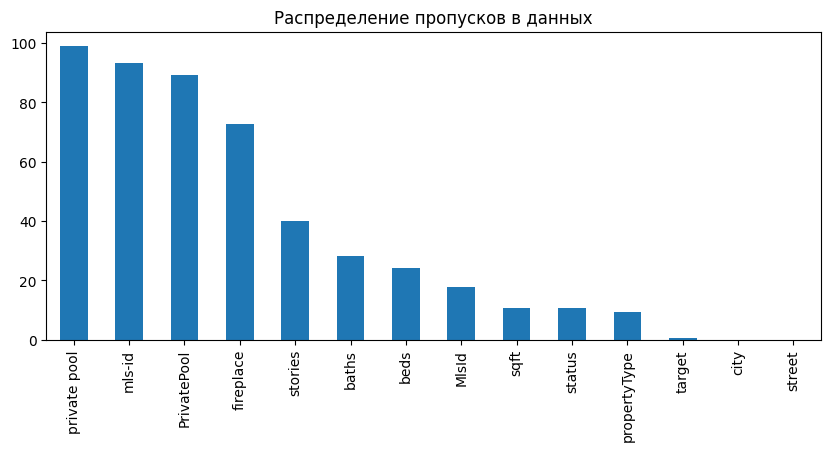

In [12]:
cols_null_percent = data_cleaned.isnull().mean()*100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
cols_with_null.plot(
    kind='bar',
    figsize=(10, 4),
    title='Распределение пропусков в данных'
);

**Вывод**

*Из графика отчётливо видно, что число пропусков в признаках private pool, mls-id, PrivatePool, fireplace  превышает 70 %. Также мы видим признаки с числом пропусков близ 0. Признаки с пропусками данных более 40% могут быть удалены. Т.к. признаки mls-id и MlsId дублируются и мы их в дальнейшем объединим, то не будем пока их удалять, а признак fireplace подлежит удалению. Признаки PrivatePool PrivatePool также подлежат удалению, т.к. даже объединив признаки мы получим процент прорусков в данных более 40%*

In [13]:
# Удалим признак fireplace PrivatePool private pool
data_cleaned.drop(['fireplace', 'private pool', 'PrivatePool'], axis=1, inplace=True)

# Удулим пропущенные строки в признаках city street, в которых есть хотя бы 1 пропуск
data_cleaned.dropna(subset=['city', 'street'], axis=0, inplace=True)

#отбрасываем строки с числом пропусков более 4 в строке:
#m = data_cleaned.shape[1]
#data_cleaned.dropna(thresh = m-4, axis=0, inplace=True)

In [14]:
#Удалим все строки где есть пропуски в целевом признаке target

data_cleaned= data_cleaned.dropna(subset='target', axis=0)
print('Пропусков в данных в признаке target:',data_cleaned.target.isnull().sum().sum())

Пропусков в данных в признаке target: 0


### 3.2. Дубликаты

Проверим данные на наличие дубликатов. Удалим их из данных.

In [15]:
data_cleaned_duplicates = data_cleaned.copy()

#Создадим маску для поиска дубликатов с помощью функции duplicated()
mask = data_cleaned.duplicated(subset=data_cleaned_duplicates.columns)
print('Дубликатов в данных:', data_cleaned_duplicates[mask].shape[0])

Дубликатов в данных: 49


In [16]:
#Удалим дубликаты из DataFrame
data_cleaned = data_cleaned_duplicates.drop_duplicates()

### 3.3. Очистка от выбросов

In [17]:
#Проведем преобразование значени целевого признака target из строчного в числовой, чтобы в дальнейшем определить возможные выбросы
import re

df_cleaned_num = data_cleaned.copy()

df_cleaned_num['target'] = df_cleaned_num['target'].apply(lambda x: int("".join(filter(str.isdigit, x))))

# Переведем значения признаков baths, sqft, beds, stories в числовые
df_cleaned_num['sqft'] = df_cleaned_num['sqft'].apply(lambda x: "".join(re.findall(r'\d+', str(x))))
df_cleaned_num['sqft'] = df_cleaned_num['sqft'].apply(lambda x: -1 if x == '' else x)
df_cleaned_num['sqft'] = df_cleaned_num['sqft'].apply(lambda x: int(x))
df_cleaned_num['sqft'] = df_cleaned_num['sqft'].replace({-1: np.nan})

df_cleaned_num['baths'] = df_cleaned_num['baths'].apply(lambda x: x if 'Bathrooms' in str(x) else re.split(r'[,. -]', str(x))[0])
df_cleaned_num['baths'] = df_cleaned_num['baths'].apply(lambda x: "".join(re.findall(r'\d+', str(x))))
df_cleaned_num['baths'] = df_cleaned_num['baths'].apply(lambda x: -1 if x == '' or x is np.nan else x)
df_cleaned_num['baths'] = df_cleaned_num['baths'].apply(lambda x: int(x))
df_cleaned_num['baths'] = df_cleaned_num['baths'].replace({-1: np.nan})

df_cleaned_num['beds'] = df_cleaned_num['beds'].apply(lambda x: np.nan if 'sqft' in str(x) or 'acres' in str(x) or 'acre' in str(x) or '$708,248' in str(x) or '$360,731' in str(x) else "".join(re.findall(r'\d+', str(x))))
df_cleaned_num['beds'] = df_cleaned_num['beds'].apply(lambda x: -1 if x == '' or x is np.nan else x)
df_cleaned_num['beds'] = df_cleaned_num['beds'].apply(lambda x: int(x))
df_cleaned_num['beds'] = df_cleaned_num['beds'].replace({-1: np.nan})

#Для перевода признака stories создадим словарь сложных для интерпретации выражений
dict_stories = {'One':1, 'Three':3, 'Tri':3, 'Two':2, '1/2':0.5, '1.5':0.5, 'Quad':4, '1 1/2 Levels':1.5,
                '1 1/2 Story':1.5, '1 Level, 1.5 Level':1.5, '1 Level, 2 Level':2, '1 Story, 2 Story':2,
               '1-2 Stories':2, '1-2 Stories, 3-4 Stories':4, '1.5 Level, Site Built, Tri-Level':3, 
               '2 Story, Tri Level':3, '3 - 5 Stories':5, '3-4 Stories':4, 'Bi-Level':2, 'Ground Level, Split Level, Two':2,
               'Ground Level, Two':2, 'Multi Level, Three or More':3, 'Multi Level, Tri Level':3, 'Multi/Split, Two':2,
               'One and One Half':1.5, 'One and One Half, Three Or More':3, 'One, Three Or More':3, 'One, Two':2, 'One, Two, Multi/Split':2,
               'Quad Level':4, 'Site Built, Tri-Level':3, 'Split Entry (Bi-Level)':2, 'Split Foyer, Tri-Level':3, 'T3-Townhouse 3+ Stories':3, 
               'Three Or More':3, 'Three Or More Levels':3, 'Three Or More, Multi/Split':3, 'Townhouse-2 Story, T3-Townhouse 3+ Stories':3,
               'Tri Level':3, 'Tri-Level':3, 'Tri/Multi Level':3, 'Triplex':3, 'Two Stories':2, 'Two Story or More':2, 
               'Two, Multi/Split':2, 'Two, Three Or More':3}

df_cleaned_num['stories'] = df_cleaned_num['stories'].replace(dict_stories)

df_cleaned_num['stories'] = df_cleaned_num['stories'].apply(lambda x: 0 if x is np.nan else x)
df_cleaned_num['stories'] = df_cleaned_num['stories'].apply(lambda x: "".join(re.findall(r'\d+\.\d+|\d+', str(x))))
df_cleaned_num['stories'] = df_cleaned_num['stories'].apply(lambda x: 1 if x == '' else x)
df_cleaned_num['stories'] = df_cleaned_num['stories'].apply(lambda x: float(x))
df_cleaned_num['stories'] = df_cleaned_num['stories'].apply(lambda x: np.nan if x == 0 else x)

In [18]:
#Выведем статистику по преобразованным числовым признакам
df_cleaned_num.describe()

,baths,sqft,beds,stories,target
count,267817.000000,3.337150e+05,263550.000000,213456.000000,3.746190e+05
mean,3.323340,6.648416e+03,5.424804,2.006761,6.447713e+05
std,22.275528,1.588714e+06,8.278889,4.338223,1.841560e+06
min,0.000000,0.000000e+00,0.000000,0.500000,1.000000e+00
25%,2.000000,1.242000e+03,3.000000,1.000000,1.869970e+05
50%,2.000000,1.800000e+03,3.000000,2.000000,3.200000e+05
75%,3.000000,2.588000e+03,4.000000,2.000000,5.820000e+05
max,750.000000,7.959794e+08,300.000000,1120.000000,1.950000e+08


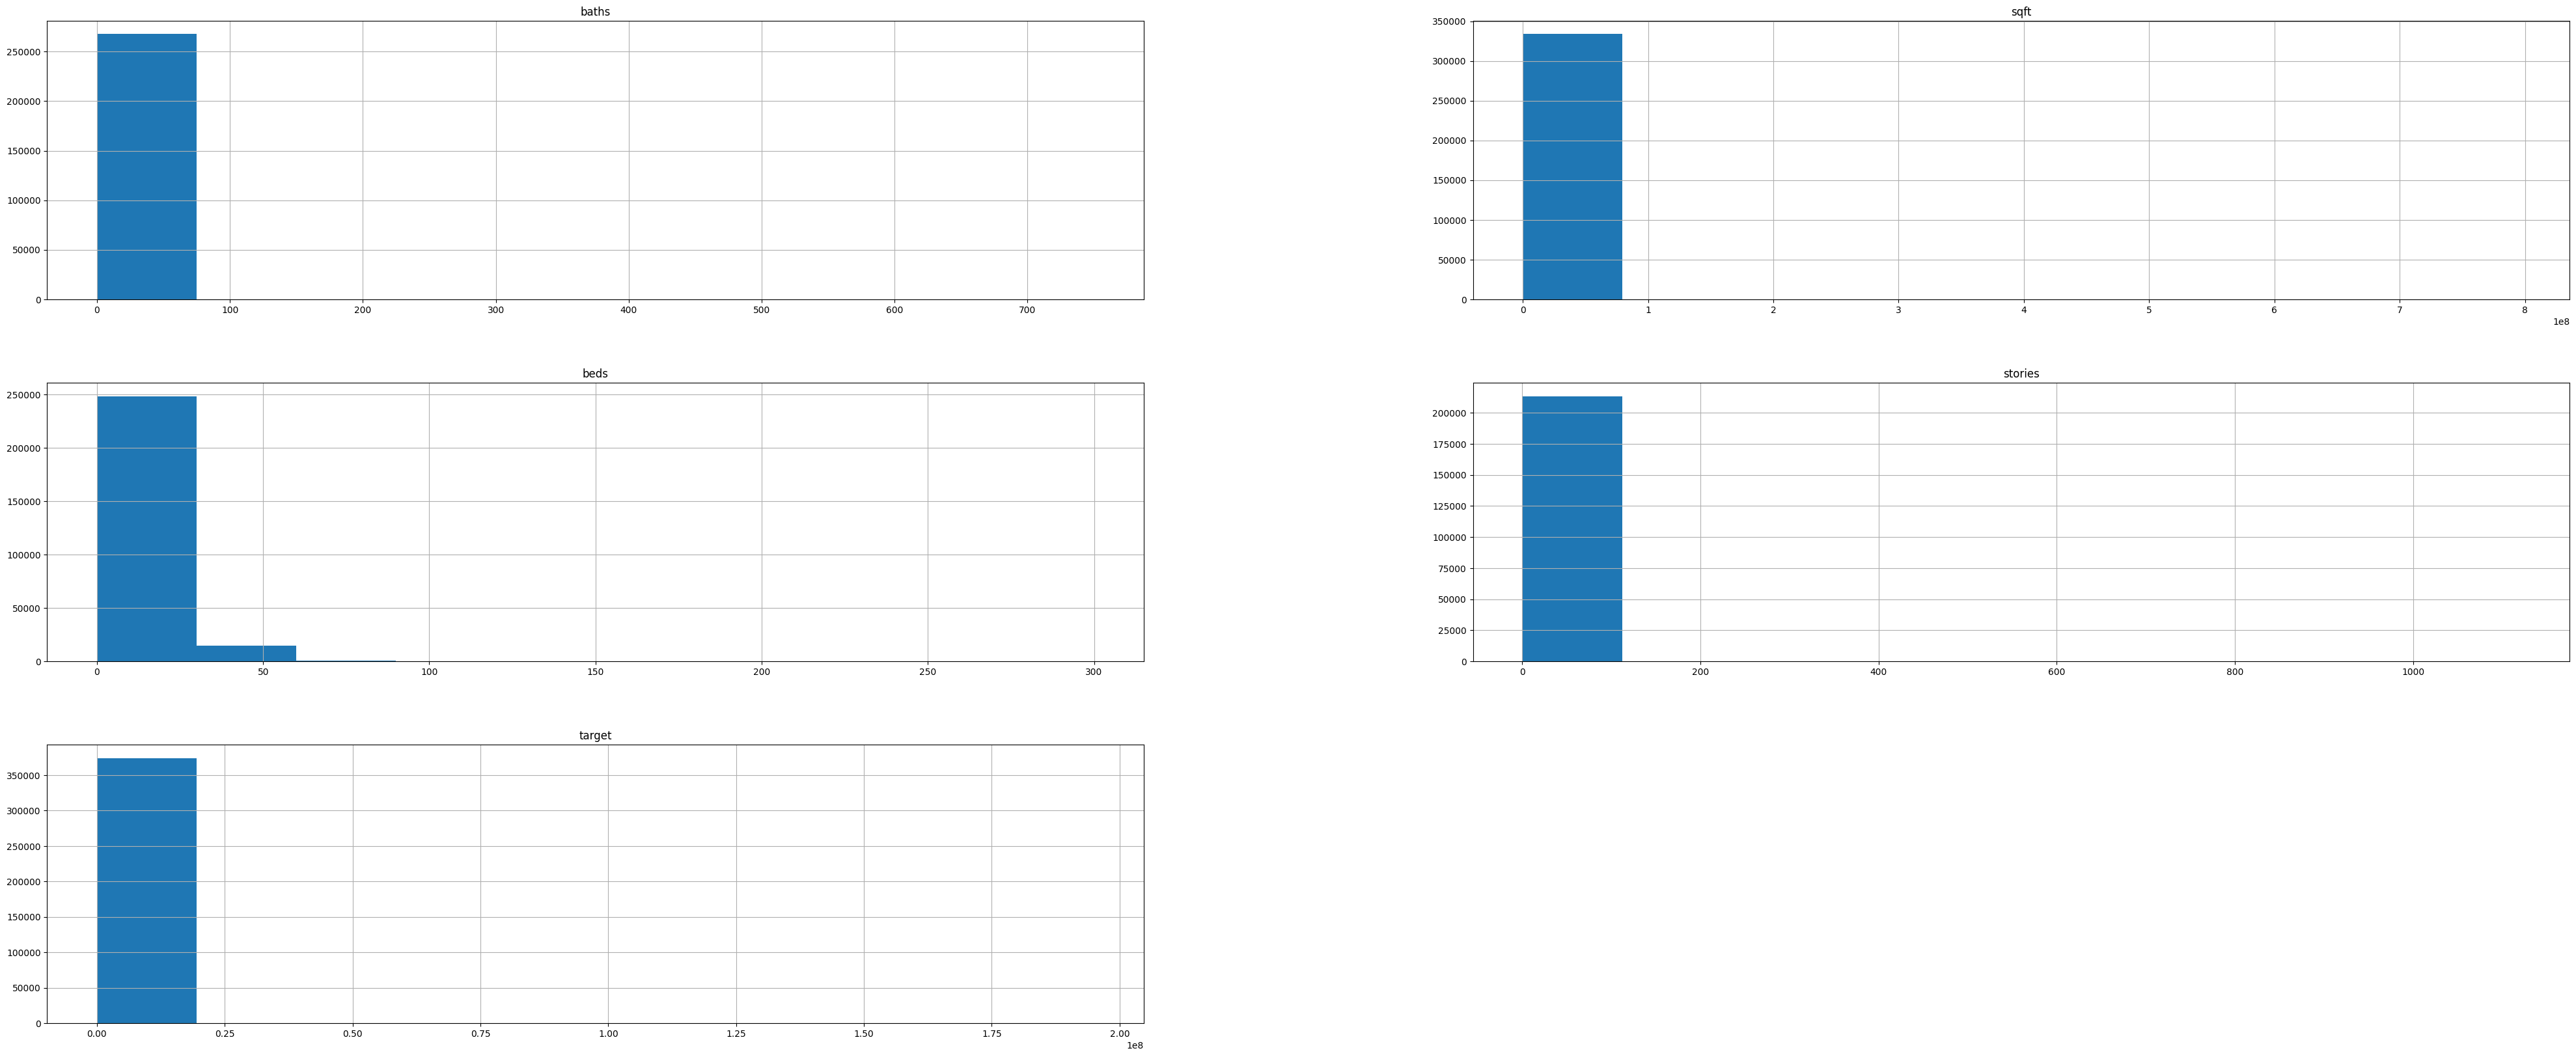

In [19]:
# Построим гистограмму для визуальной оценки признаков на нормальность
df_cleaned_num.hist(figsize=(50, 20));

**Вывод:**

*Гистотраммы распределения числовых признаков показывают большое что данные не распределены нормально*

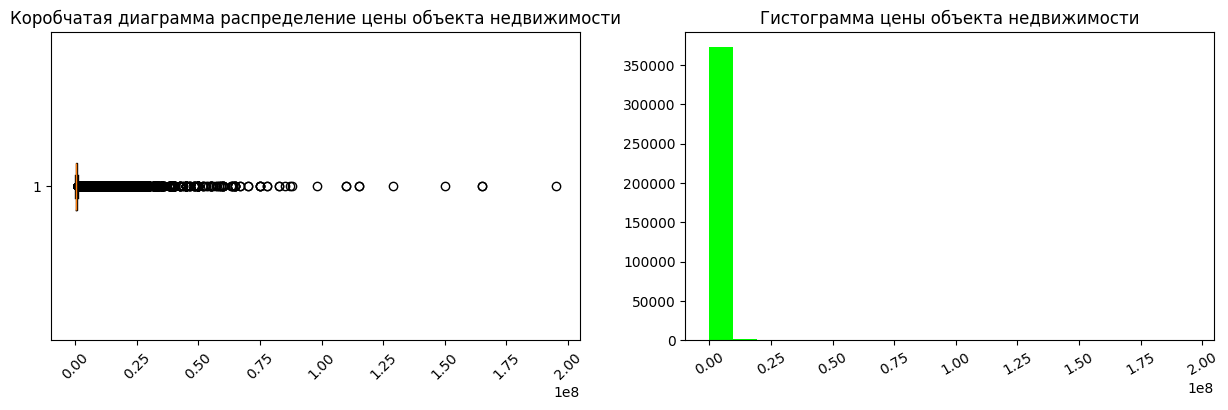

In [20]:
# Дополнительно начертим гистограмму для целевого признака, чтобы определить по какому закону происходит распределение признаков

#визуализация систем координат
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))

#столбчатая диаграмма
axes[0].boxplot(x=df_cleaned_num['target'], vert=False)
axes[0].set_title('Коробчатая диаграмма распределение цены объекта недвижимости')
axes[0].xaxis.set_tick_params(rotation=45)

#гистограмма
axes[1].hist(x=df_cleaned_num['target'], 
             color='lime', bins = 20)
axes[1].set_title('Гистограмма цены объекта недвижимости');
axes[1].xaxis.set_tick_params(rotation=30)

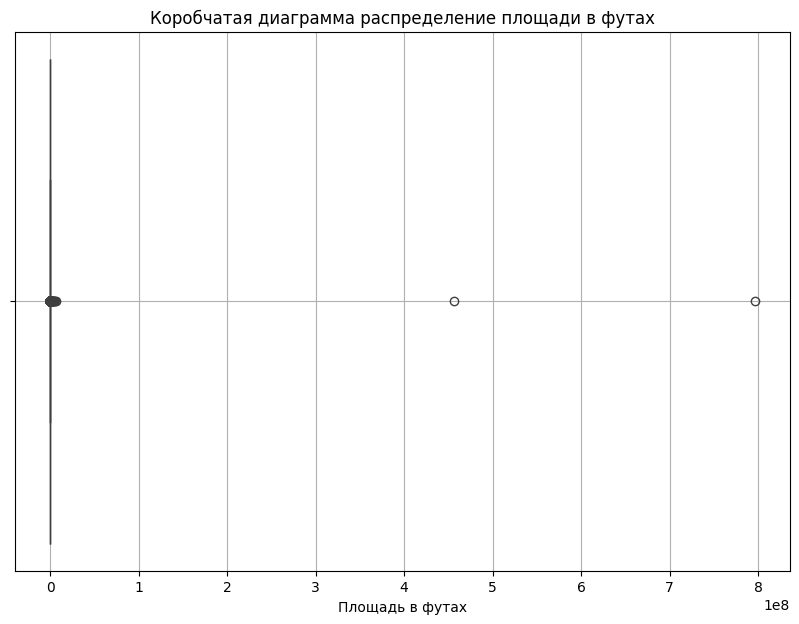

In [21]:
# Начертим коробчатую диаграмму признака sqft для определения выбросов

fig = plt.figure(figsize=(10, 7))
boxplot = sns.boxplot(
    data=df_cleaned_num,
    x='sqft',
    orient='h',
    width=0.9
)
boxplot.set_title('Коробчатая диаграмма распределение площади в футах');
boxplot.set_xlabel('Площадь в футах');
boxplot.grid()

**Вывод:**

*Коробчатые диаграммы и гисиотраммы признаков target и sqft показывают большое наличие выбросов произведем логарифмирование целевого признака перед удалением выбросов, т.к. для использования метода межквартильного размаха енобходимо, чтобы данные были распределены приблизительно нормально*

In [22]:
# Произведем логарифмирование целевого признака

df_cleaned_num_log = df_cleaned_num.copy()

df_cleaned_num_log['target'] = np.log(df_cleaned_num_log['target'] +1)

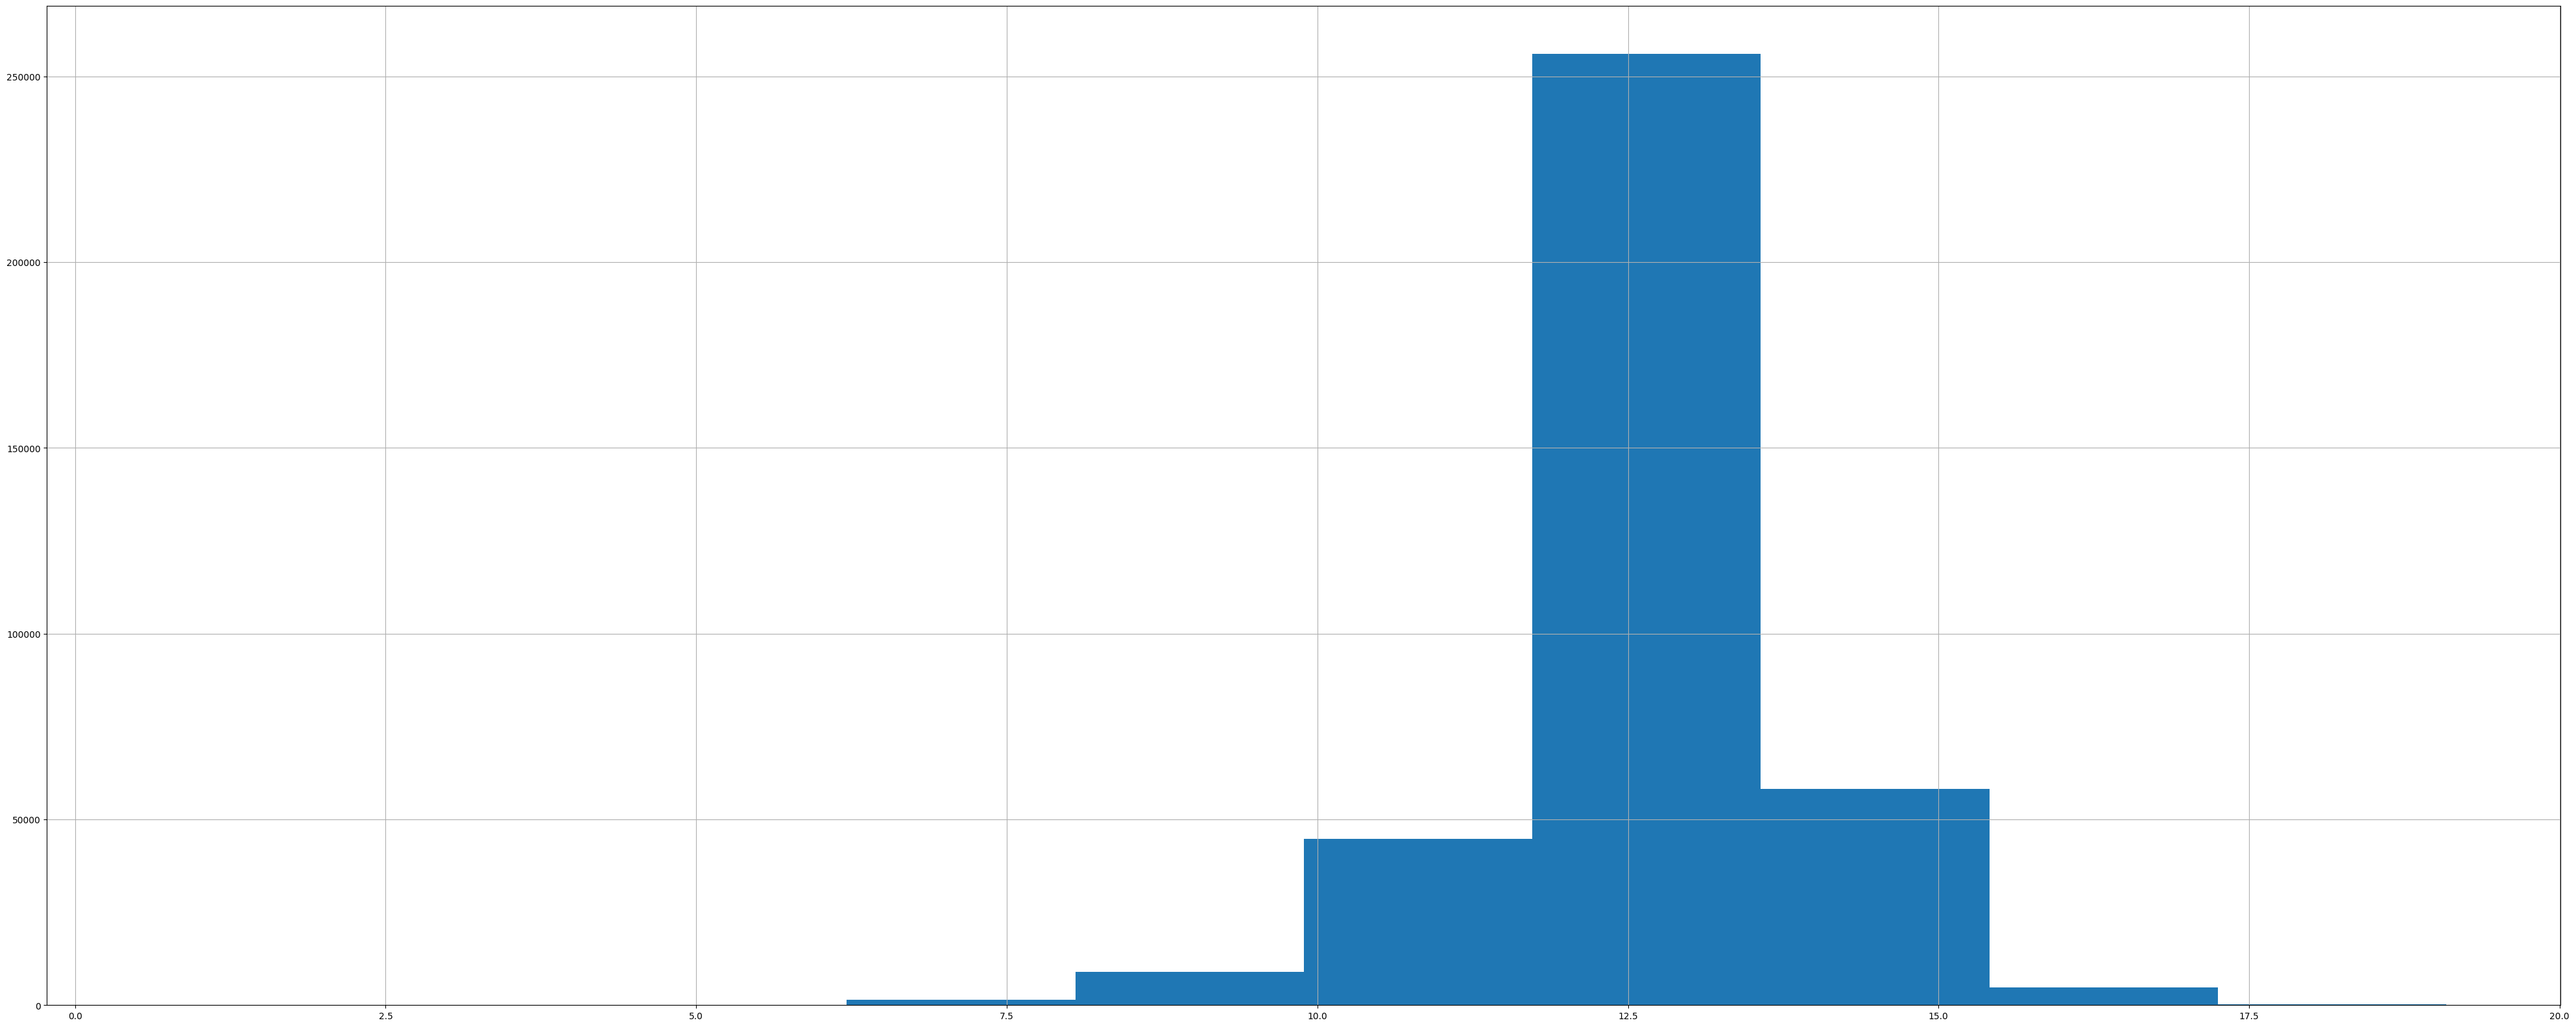

In [23]:
# Построим гистограмму для визуальной целевого признака на нормальность после логарифмирования

df_cleaned_num_log['target'].hist(figsize=(50, 20));

**Вывод:**

*Гистограмма распределения целевого признака показывает, что после логарифмирования целевой признак распределен приблизительно нормально. Теперь можно произвести удаление признаков методом межквартильного размаха*

In [24]:
# Удалим выбросы методом межквартильного размаха из признаков target

df_cleaned = df_cleaned_num_log.copy()

x = df_cleaned['target']
quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
iqr = quartile_3 - quartile_1
lower_bound = quartile_1 - (iqr * 1.5)
upper_bound = quartile_3 + (iqr * 1.5)
outliers = df_cleaned[(x<lower_bound) | (x > upper_bound)]
df_cleaned = df_cleaned[(x>lower_bound) & (x <= upper_bound)]
print(f'Нижняя граница: {round(lower_bound)}')
print(f'Верхняя граница:{round(upper_bound)}')
print(f'Результирующее число записей: {(df_cleaned.shape[0])}')

Нижняя граница: 10
Верхняя граница:15
Результирующее число записей: 347886


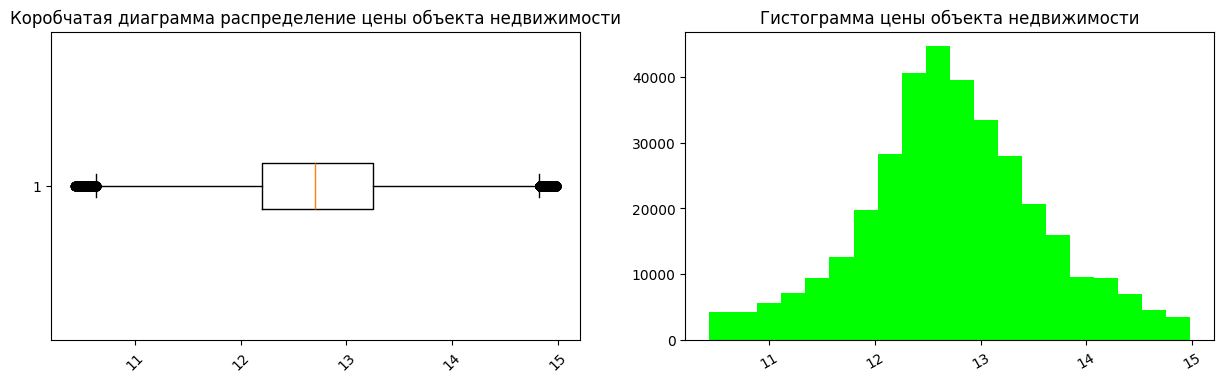

In [25]:
# Начертим столбчатую диаграмму и гистограмму признаков target после удаления выбросов

#визуализация систем координат
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
#столбчатая диаграмма
axes[0].boxplot(x=df_cleaned['target'], vert=False)
axes[0].set_title('Коробчатая диаграмма распределение цены объекта недвижимости')
axes[0].xaxis.set_tick_params(rotation=45)

#гистограмма
axes[1].hist(x=df_cleaned['target'], 
             color='lime', bins = 20)
axes[1].set_title('Гистограмма цены объекта недвижимости');
axes[1].xaxis.set_tick_params(rotation=30)

**Вывод**

*Картина распределения признака target значительно улучшилась. Коробчатая диаграмма показывает отсутствие  выбросов. Гистограмма распределения четко показывает нормальное распределение* 

In [26]:
# Удалим выбросы вручную из оставшихся числовых признаков baths и beds

outliers = df_cleaned[df_cleaned['baths']>= 100].index
df_cleaned.drop(outliers, axis=0, inplace=True)

outliers = df_cleaned[df_cleaned['beds']> 20].index
df_cleaned.drop(outliers, axis=0, inplace=True)

#Удалим вручную выбросы из признака sqft
outliers = df_cleaned[df_cleaned['sqft']> df_cleaned['sqft'].quantile(0.95).item()].index
df_cleaned.drop(outliers, axis=0, inplace=True)

#Удалим вручную выбросы из признака stories
outliers = df_cleaned[df_cleaned['stories']> 20].index
df_cleaned.drop(outliers, axis=0, inplace=True)

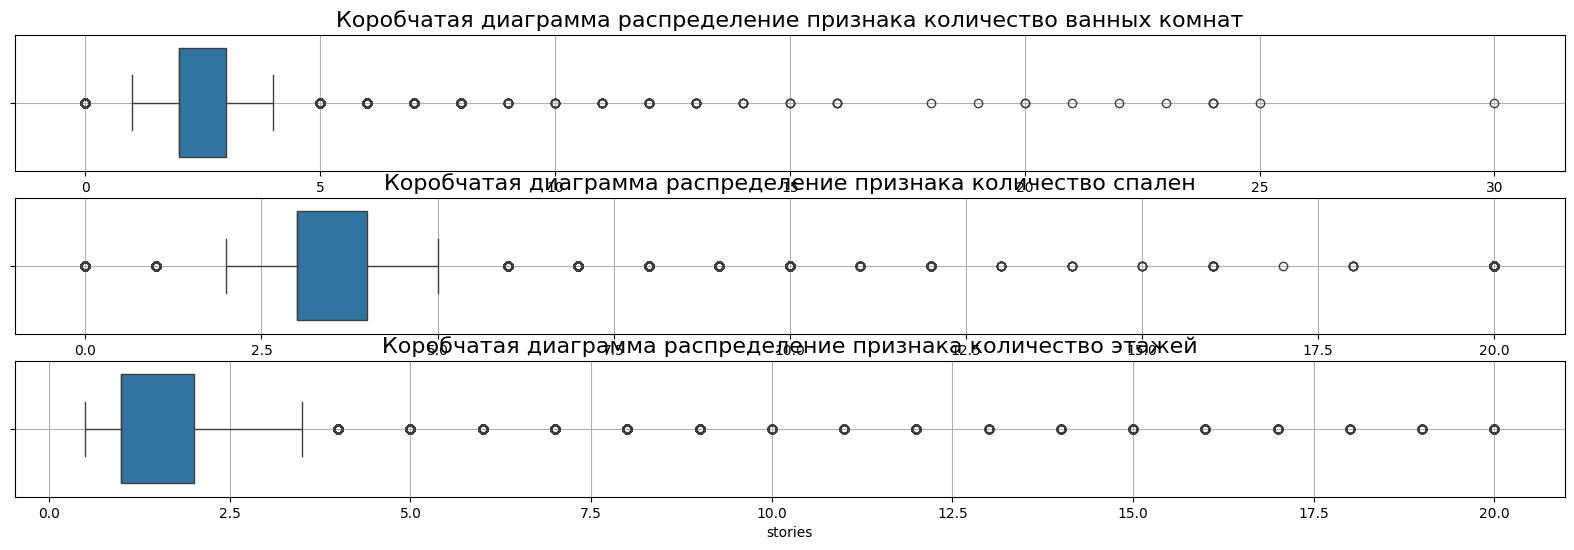

In [27]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(20,6))
boxplot = sns.boxplot(
    data=df_cleaned,
    x='baths',
    orient='h',
    ax=axes[0]
);
boxplot.set_title('Коробчатая диаграмма распределение признака количество ванных комнат', fontsize=16);
boxplot.grid()

boxplot = sns.boxplot(
    data=df_cleaned,
    x='beds',
    orient='h',
    ax=axes[1]
)
boxplot.set_title('Коробчатая диаграмма распределение признака количество спален', fontsize=16);
boxplot.grid()

boxplot = sns.boxplot(
    data=df_cleaned,
    x='stories',
    orient='h',
    ax=axes[2]
);
boxplot.set_title('Коробчатая диаграмма распределение признака количество этажей', fontsize=16);
boxplot.grid()

**Вывод**

*Картина распределения признаков значительно улучшилась. Коробчатые диаграммы показывают отсутствие значительных  выбросов* 

### 3.4. Заполнение пропушенных значений

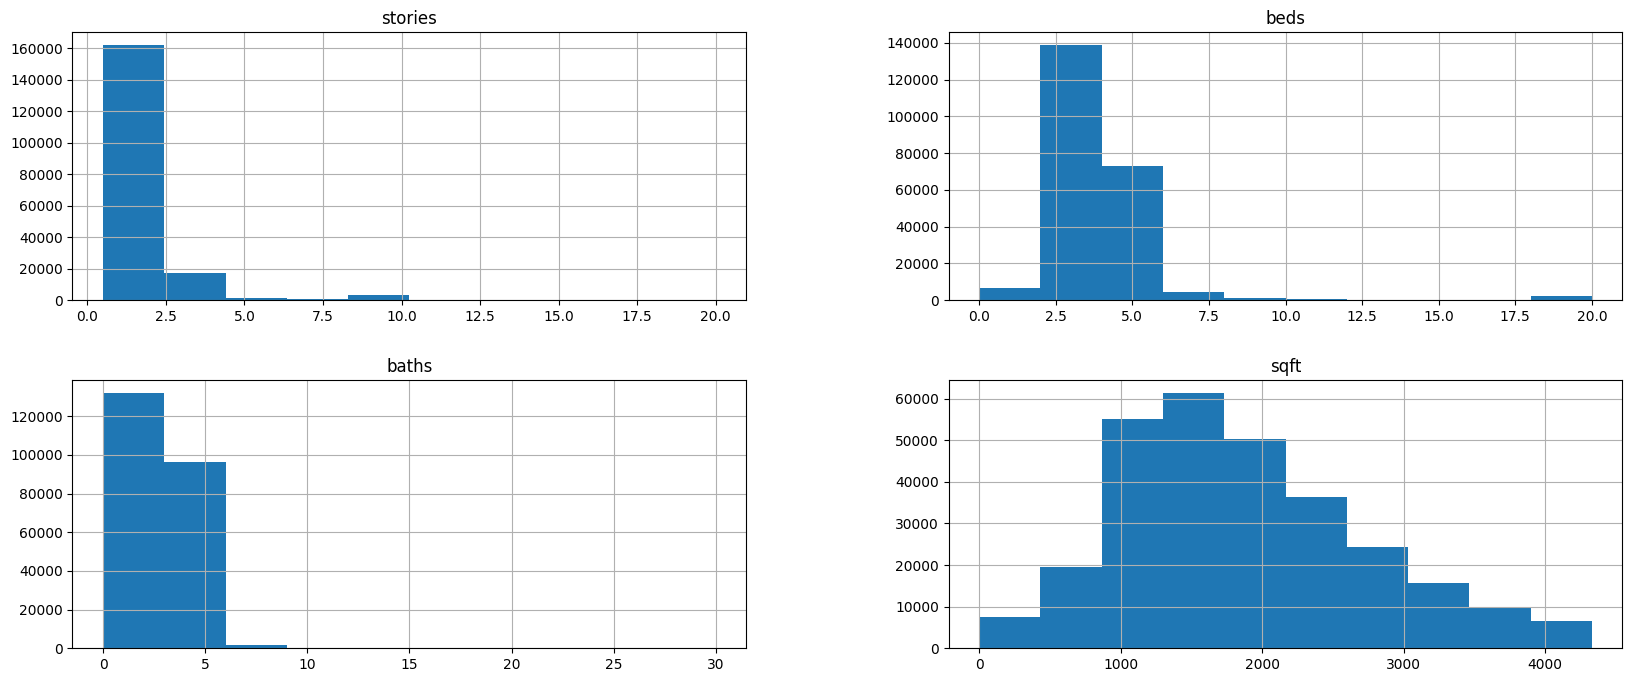

In [28]:
# Начертим гистограмму признаков с пропущенными значениями

cols_null_percent = df_cleaned.isnull().mean()*100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
cols = cols_with_null.index
df_cleaned[cols].hist(figsize=(20, 8));

**Выводы:**

- *Для распределений, похожих на логнормальное, где пик близ нуля, предпочтительнее использовать медианное значение. Это признак признак stories.*
- *Для распределений, похожих на нормальное признак sqft предпочтительнее использовать среднее значение* 
- *Для числовых и дискретных (например, число этажей, школьная квота), то их заполнение средним/медианой является ошибочным, так как может получиться число, которое не может являться значением этого признака.  Такие признаки заполняют либо модой, либо округляют до целого числа среднее/медиану. Заполним их модой Это признаки baths и beds*
- *Категориальные признаки заполним модальным значением. Это признаки 'city', 'status', 'propertyType'.*
- *В признаках 'homeFacts' и 'schools' итсутствуют пропуски. Дополнительно они требует предварительной десериализации.*
- *В категориальных признаках 'street', 'state' и в числовом 'zipcode' отсутствуют пропуски*

In [29]:
#создаем копию исходной таблицы
fill_data = df_cleaned.copy()

#создаем словарь имя столбца: число(признак) на который надо заменить пропуски:
values = {
    'stories': fill_data['stories'].median(),
    'baths': fill_data['baths'].mode()[0],
    'beds': fill_data['beds'].mode()[0],
    'status': fill_data['status'].mode()[0],
    'propertyType': fill_data['propertyType'].mode()[0],
    'city': fill_data['city'].mode()[0],
    'sqft': round(fill_data['sqft'].mean())
}
#заполняем пропуски в соответствии с заявленным словарем:
fill_data = fill_data.fillna(values)
#выводим результирующую долю пропусков:
fill_data.isnull().mean()

status          0.000000
propertyType    0.000000
street          0.000000
baths           0.000000
homeFacts       0.000000
city            0.000000
schools         0.000000
sqft            0.000000
zipcode         0.000000
beds            0.000000
state           0.000000
stories         0.000000
mls-id          0.927845
MlsId           0.187052
target          0.000000
dtype: float64

In [827]:
# Сохраним полученный DataFrame
df_cleaned = fill_data.copy()
df_cleaned.to_csv('data/df_cleaned.csv')

NameError: name 'fill_data' is not defined

## 4. Разведывательный анализ EDA

### 4.1. Перевод остальных признаков в числовые

In [237]:
#Загрузим сохраненный DataFrame
df_cleaned_eda = pd.read_csv('data/df_cleaned.csv', index_col=0)

In [238]:
#Переведем признаки mls-id и MlsId в числовые и объединим в один MlsId
df_cleaned_eda['mls-id'] = df_cleaned_eda['mls-id'].apply(lambda x: 0 if x is np.nan else 1)
df_cleaned_eda['MlsId'] = df_cleaned_eda['MlsId'].apply(lambda x: 0 if x is np.nan else 1)
df_cleaned_eda['MLS'] = df_cleaned_eda['MlsId'] + df_cleaned_eda['mls-id']

#Удалим признаки mls-id и MlsId
df_cleaned_eda.drop(['mls-id', 'MlsId'], axis=1, inplace=True)

In [239]:
#Удалим признак index и заново проиндексируем DataFrame	
df_cleaned_eda = df_cleaned_eda.reset_index(drop=True)

In [240]:
#Создадим словарь для группировки статуса объектов недвижимости
dict_status = {'active':'for sale','foreclosed': 'foreclosed', 'foreclosure':'foreclosed', 'pf':'foreclosed', 'backups':'backup', 
                'back':'backup', 'backup':'backup','contract': 'contract', 'ct': 'contract', 'contingency':'contingency', 
                'contingencies':'contingency', 'contingent':'contingency', 'escape':'escape',
                'inspection':'inspection', 'diligence': 'for sale', 'activated': 'for sale',
                'offer':'backup', 'auction': 'auction', 'cooling': 'backup', 'closed':'closed',
                 'new':'new', 'for sale': 'for sale', 'pending': 'pending',
               'p':'pending', 'continue':'continue', 'coming soon':'new', 'listing extended': 'for sale'
               }
def get_dict_status(args):
    '''Функция выявления корректного статуса объекта недвижимости'''
    for i in dict_status.keys():
        if i in (str(args)).lower():
            return dict_status[i]
    else:
        return args
    
df_cleaned_eda['status'] = df_cleaned_eda['status'].apply(get_dict_status)        

In [241]:
#Проверим какие группы и какое количество объектов в каждой группе получилось
print(df_cleaned_eda['status'].value_counts())
print(f'Объекты недвижимости со статусом: {df_cleaned_eda.status.value_counts().tail(4).index} подлежат удалению из-за их неопределенности(выбросы) и незначительного влияния на DataFrame в целом(малое количество объектов)')

status
for sale       294035
contract         8239
foreclosed       8185
pending          5089
new               762
backup            471
contingency       185
C                  30
continue           12
closed              4
for rent            1
Name: count, dtype: int64
Объекты недвижимости со статусом: Index(['C', 'continue', 'closed', 'for rent'], dtype='str', name='status') подлежат удалению из-за их неопределенности(выбросы) и незначительного влияния на DataFrame в целом(малое количество объектов)


In [242]:
# Удалить столбцы, соответствующие маске с неопределенным статусом
mask1 = df_cleaned_eda.status != 'C'
mask2 = df_cleaned_eda.status != 'continue'
mask3 = df_cleaned_eda.status != 'closed'
mask4 = df_cleaned_eda.status != 'for rent'

df_temp_filtered = df_cleaned_eda[mask1 & mask2 & mask3 & mask4].reset_index(drop=True)

In [243]:
print(f'Объекты недвижимости со статусом: {df_temp_filtered.status.value_counts().tail(3).index} подлежат переименованию в other')

vc = df_temp_filtered['status'].value_counts()
df_temp_filtered['status'] = df_temp_filtered['status'].apply(lambda x: x if vc[x] > 1000 else 'other').reset_index(drop=True)

Объекты недвижимости со статусом: Index(['new', 'backup', 'contingency'], dtype='str', name='status') подлежат переименованию в other


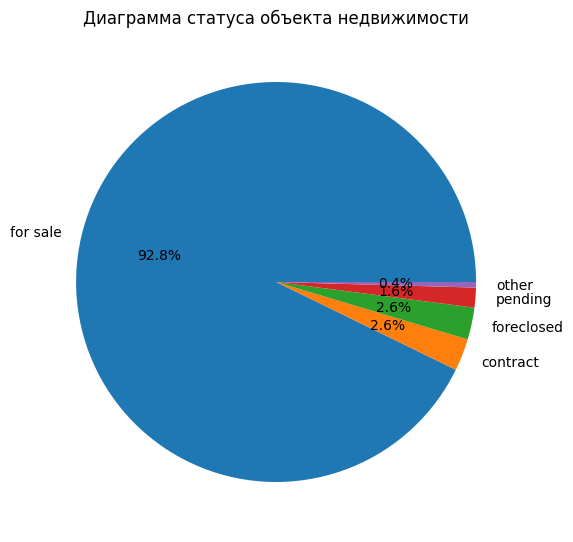

In [244]:
pie_data = df_temp_filtered['status'].value_counts()

fig = plt.figure(figsize=(5,5))
axes = fig.add_axes([0,0,1,1])
axes.pie(
    pie_data,
    labels=pie_data.index,
    autopct='%.1f%%'
)
title= axes.set_title('Диаграмма статуса объекта недвижимости')

**Вывод:**

*Круговая диаграмма показывает, что наиболее распрастраненный тип статуса недвижимости for sale*

In [245]:
#Удалим дублирование элементов в признаке propertyType с помощью функции get_propertype_double
def get_propertype_double(arg):
    '''Функция исправления дублирования жаргонных сокращений'''
    arg = arg.lower()
    for i, j in ('mo2 le', 'mobile'), ('mo2le', 'mobile'), ('ca2 n', 'cabin'), ('ca2n', 'cabin'), ('manufactured home (house)', 'mobile'), ('prefab', 'mobile'), ('modular', 'mobile'), ('single family home', 'single family'), ('single-family home', 'single family'), ('mid century', 'midcentury'), ('mid-century', 'midcentury'):
        arg = arg.replace(i, j)
    return arg

df_temp_filtered.propertyType = df_temp_filtered.propertyType.apply(get_propertype_double)

In [246]:
#Произведем в ручном режиме предварительную группировку данных в признаке propertyType с помощью словаря
propertyType_dict = {'mobile':'mobile', 'carriage':'mobile', 'cabin':'cabin', 'apartment':'apartment', 
                   'single family':'single family', '1 1/2 s':'single family', '1 story':'single family', 'bungalow':'single family', 'singlefamilyresidence':'single family', 'one story':'single family', 'single detached':'single family', 'single':'single family',
                     'cluster home':'cluster home','chalet':'single family',
                   'condo':'condo', 'co-op':'coop', 'coop':'coop', 'attached':'duplex', 'duplex':'duplex',
                   'townhome':'townhouse', 'cluster home':'townhouse', 'townhouse':'townhouse', 'other':'other', 'transitional':'traditional',
                   'cape':'cape cod', 'colonial':'colonial home', 'bi-level':'colonial home', '2 stor':'colonial home', '4-square':'colonial home', 'two story':'colonial home',
                   '2-stor':'colonial home', '2.5 stor':'colonial home' ,'3 stor':'colonial home', 'bilevel':'colonial home',
                   '3+ stor':'colonial home', '4+ floor':'colonial home', 'contemporary':'contemporary',
                   'cottage':'cottage', 'craftsman':'craftsman', 'greek':'greek revival', 'farmhouse':'farmhouse',
                   'french':'french country', 'mediterranean':'coastal', 'midcentury':'midcentury',
                   'ranch':'ranch', 'split-level':'split', 'tudor':'tudor', 'victorian':'victorian',
                   'european':'european', 'log home':'log home', 'log':'log home', 'a-frame':'a-frame',
                  'coastal':'coastal', 'florida':'coastal', 'miscellaneous':'other', 'penthouse': 'penthouse', 'split':'split',
                   'multi-family':'multi family', 'multi family':'multi family', 'land':'land'  
                  }

def get_propertyType_dict(arg):
    '''Функция группировки по типу объекта недвижимости'''
    for i in propertyType_dict.keys():
        if i in (str(arg)).lower():
            return propertyType_dict[i]
    else:
        return arg
    
df_temp_filtered['propertyType'] = df_temp_filtered['propertyType'].apply(get_propertyType_dict)        

In [247]:
# Удалим значения которые встречаются менее 100 раз
mask = df_temp_filtered['propertyType'].value_counts() > 100
keep_values = mask[mask].index
# Отфильтруем DataFrame
df_temp_filtered = df_temp_filtered[df_temp_filtered['propertyType'].isin(keep_values)]

#Удалим строки со значением apartment, т.к это съёмная квартира и ее нельзя купить;
mask_apart =  df_temp_filtered['propertyType'] != 'apartment'
df_temp_filtered = df_temp_filtered[mask_apart]

#Удалим строки со значением mobile, т.к этот тип не являяется недвижимостью
mask_apart =  df_temp_filtered['propertyType'] != 'mobile'
df_temp_filtered = df_temp_filtered[mask_apart]


#Остальные значения,которые меньше 500, заменим на 'other'
vc = df_temp_filtered['propertyType'].value_counts()
df_temp_filtered['propertyType'] = df_temp_filtered['propertyType'].apply(lambda x: x if vc[x] > 7000 else 'other')

df_temp_filtered = df_temp_filtered.reset_index(drop=True)

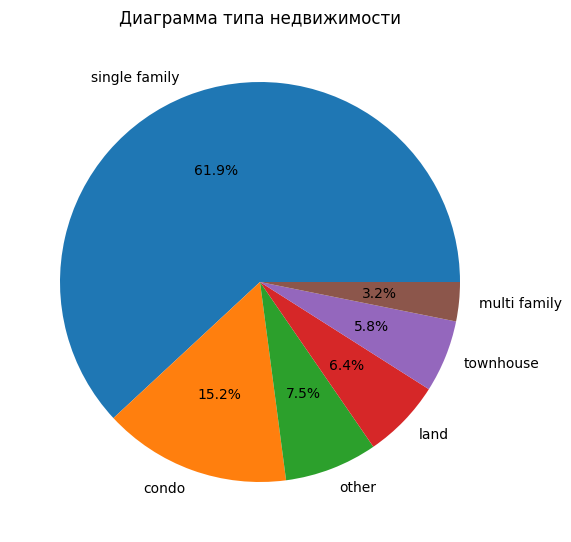

In [248]:
pie_data = df_temp_filtered['propertyType'].value_counts()

fig = plt.figure(figsize=(5,5))
axes = fig.add_axes([0,0,1,1])
axes.pie(
    pie_data,
    labels=pie_data.index,
    autopct='%.1f%%'
)
title= axes.set_title('Диаграмма типа недвижимости')

**Вывод:**

*Круговая диаграмма показывает, что наиболее распрастраненный тип недвижимости single family, наименее multi family*

**Вывод**

*Наиболее распрастраненный тип недвижимости после группировки Single family. Пропуски данных в дальнейшем будем заменять этим типом*

In [249]:
import ast
#Десериализуем признак homeFacts
my_dict = {}

for i in df_temp_filtered.homeFacts:
    facts = ast.literal_eval(i)['atAGlanceFacts']
    row = {item['factLabel']: item['factValue'] for item in facts}
    for j in row:
        my_dict.setdefault(j, []).append(row[j])


#Объединим в общий DataFrame
df_temp_filtered = df_temp_filtered.join(
pd.DataFrame(my_dict),
how='outer'
)

In [250]:
#Создадим новый признак, который показывает сколько лет зданию после постройки
df_temp_filtered['Year built'] = df_temp_filtered['Year built'].apply(lambda x: "".join(re.findall(r'\d+', str(x))))
df_temp_filtered['Year built'] = df_temp_filtered['Year built'].apply(lambda x: -1 if x == '' else x)
df_temp_filtered['Year built'] = df_temp_filtered['Year built'].apply(lambda x: int(x))
df_temp_filtered['Year built'] = df_temp_filtered['Year built'].replace({-1: np.nan})
#Сразу удалим выбросы со значением более текущего года постройки
mask_year_built =  (df_temp_filtered['Year built'] < 2026) | (df_temp_filtered['Year built'].isna())
df_temp_filtered = df_temp_filtered[mask_year_built]
df_temp_filtered['build_years'] = 2026 - df_temp_filtered['Year built']

#Создадим новый признак, который показывает сколько лет зданию после реконструкции
df_temp_filtered['Remodeled year'] = df_temp_filtered['Remodeled year'].apply(lambda x: "".join(re.findall(r'\d+', str(x)[0:4])))
df_temp_filtered['Remodeled year'] = df_temp_filtered['Remodeled year'].apply(lambda x: -1 if x == '' else x)
df_temp_filtered['Remodeled year'] = df_temp_filtered['Remodeled year'].apply(lambda x: int(x))
df_temp_filtered['Remodeled year'] = df_temp_filtered['Remodeled year'].replace({-1: np.nan})
df_temp_filtered['Remodeled year'] = df_temp_filtered['Remodeled year'].replace({0: np.nan})
df_temp_filtered['remodeled_years'] = 2026 - df_temp_filtered['Remodeled year']

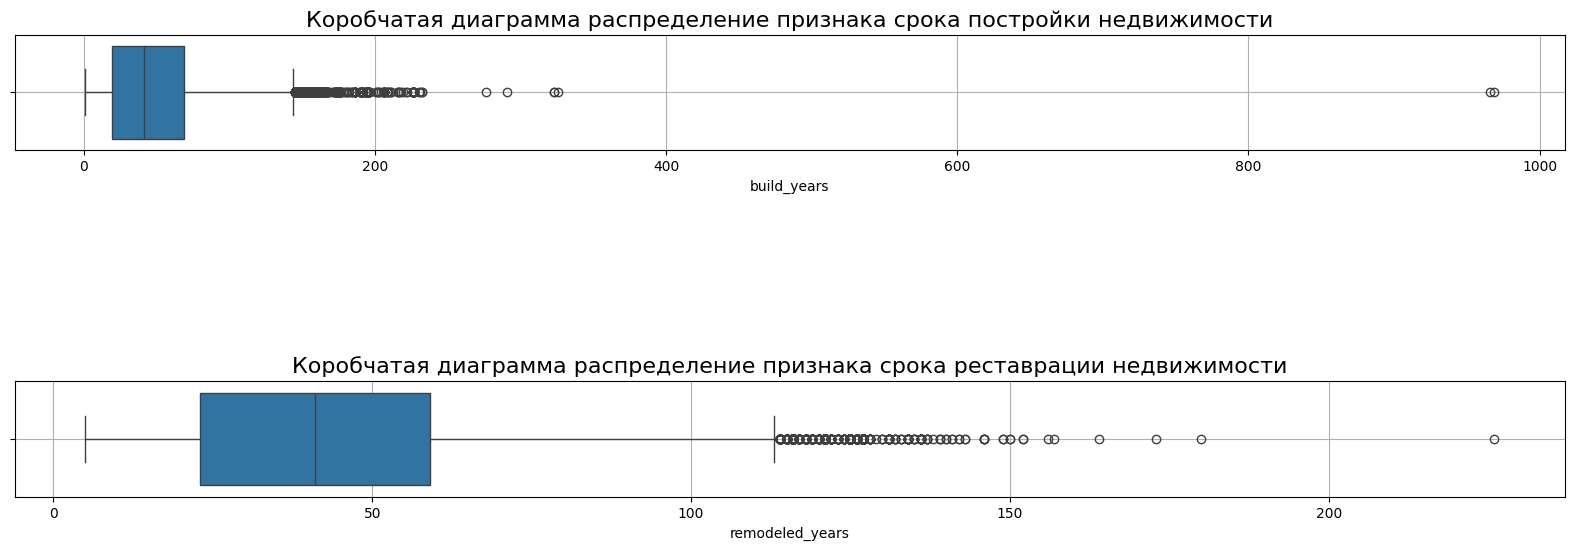

In [251]:
#Начертим коробчатые диаграмы вновь образованных признаков, чтобы проверить наличие выбросов
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20,6))
plt.subplots_adjust(hspace=2, wspace=1) 
boxplot = sns.boxplot(
    data=df_temp_filtered,
    x='build_years',
    orient='h',
    ax=axes[0]
);
boxplot.set_title('Коробчатая диаграмма распределение признака срока постройки недвижимости', fontsize=16);
boxplot.grid()
boxplot = sns.boxplot(
    data=df_temp_filtered,
    x='remodeled_years',
    orient='h',
    ax=axes[1]
);
boxplot.set_title('Коробчатая диаграмма распределение признака срока реставрации недвижимости', fontsize=16);
boxplot.grid()

**Выводы**

*Коробчатые диаграммы показывают наличие выбросы в признаке build_years со значениями более 170 лет и в признаке remodeled_years более 120 лет*

In [252]:
#Очистим признак build_years
mask_build_years =  (df_temp_filtered['build_years'] < 170) | (df_temp_filtered['build_years'].isna())
df_temp_filtered = df_temp_filtered[mask_build_years]

#Очистим признак remodeled_years
mask_remodeled_years =  (df_temp_filtered['remodeled_years'] < 120) | (df_temp_filtered['remodeled_years'].isna())
df_temp_filtered = df_temp_filtered[mask_remodeled_years]

#Создадим новый признак, который показывает сколько лет зданию после постройки или реконструкции
df_temp_filtered['full_build_years'] = df_temp_filtered[['build_years', 'remodeled_years']].min(axis=1)

#Удалим лишние признаки Remodeled year Year built remodeled_years build_years
df_temp_filtered.drop(['remodeled_years', 'Remodeled year', 'Year built', 'build_years'], axis=1, inplace=True)

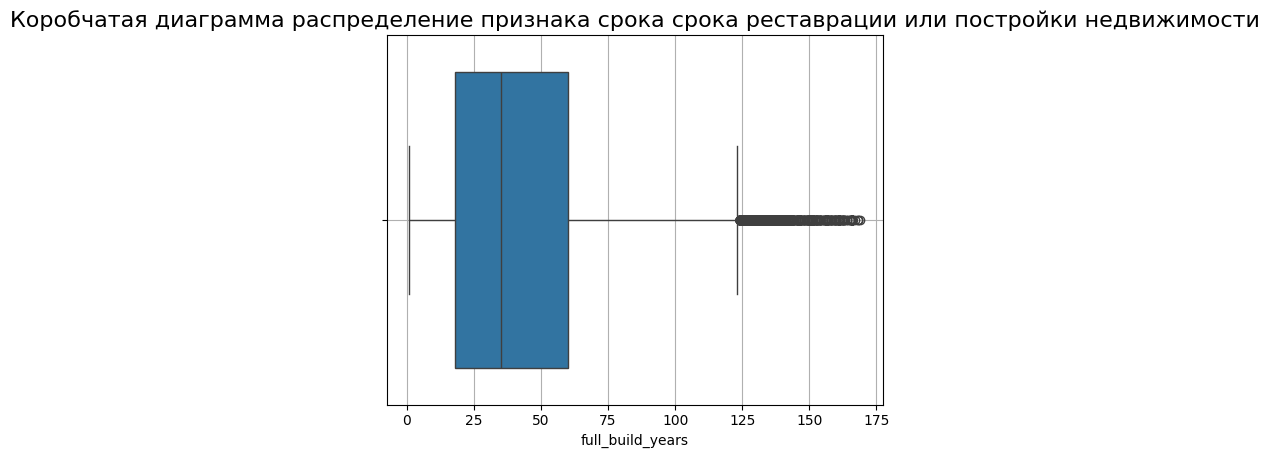

In [253]:
#Проверим на наличие выбросов вновь образованного признака срока реставрации или постройки недвижимости
boxplot = sns.boxplot(
    data=df_temp_filtered,
    x='full_build_years',
    orient='h'
);
boxplot.set_title('Коробчатая диаграмма распределение признака срока срока реставрации или постройки недвижимости', fontsize=16);
boxplot.grid()

**Выводы**

*Коробчатая диаграмма показывает отсутствие выбросов в признаке full_build_years*

In [254]:
#Объединим признаки Cooling и Heating в признак Heating_Cooling предварительно заменив значения строчные значения nan на np.nan
df_temp_filtered['Heating'] = df_temp_filtered['Heating'].apply(lambda x: np.nan if x == 'nan' else x)
df_temp_filtered['Cooling'] = df_temp_filtered['Cooling'].apply(lambda x: np.nan if x == 'nan' else x)
df_temp_filtered['Heating_Cooling'] = df_temp_filtered['Heating'] + ' ' + df_temp_filtered['Cooling']

#Произведем в ручном режиме предварительную группировку данных в признаке Heating с помощью словаря
Heating_dict = {'gas':'gas', 'g-':'gas', 'propane':'gas', 'geothermal':'geothermal', 'elecrtic':'forced air', 'electric':'forced air', 
                'wood':'furnace', 'furnace':'furnace', 'central':'central', 'solar':'solar', 'oil':'oil', 'kerosene':'oil',
                'fireplace': 'furnace', 'wood,':'furnace', 'wood-burning':'furnace', 'wood/coal,':'furnace', 'wood/oil':'furnace',
                'woodburning':'furnace', 'woodpellet':'furnace','woodstove':'furnace'
               }

def get_Heating_dict(arg):
    '''Функция группировки по виду обогрева'''
    for i in Heating_dict.keys():
        if i in (str(arg)).lower():
            return Heating_dict[i]
    else:
        return arg

#Применим функцию get_Heating_dict для группировки данных
df_temp_filtered['Heating_Cooling'] = df_temp_filtered['Heating_Cooling'].apply(lambda x: str(x).lower())
df_temp_filtered['Heating_Cooling'] = df_temp_filtered['Heating_Cooling'].apply(get_Heating_dict)

# Преобразуем данные у которых меньше 10000 в значение other
vc = df_temp_filtered['Heating_Cooling'].value_counts()
df_temp_filtered['Heating_Cooling'] = df_temp_filtered['Heating_Cooling'].apply(lambda x: x if vc[x] > 10000 else 'other')

#Заполним пропущенные значения на np.nan
df_temp_filtered.Heating_Cooling = df_temp_filtered.Heating_Cooling.apply(lambda x: np.nan if x == ' ' else x)

#Удалим признаки Cooling и Heating
df_temp_filtered.drop(['Heating', 'Cooling'], axis=1, inplace=True)

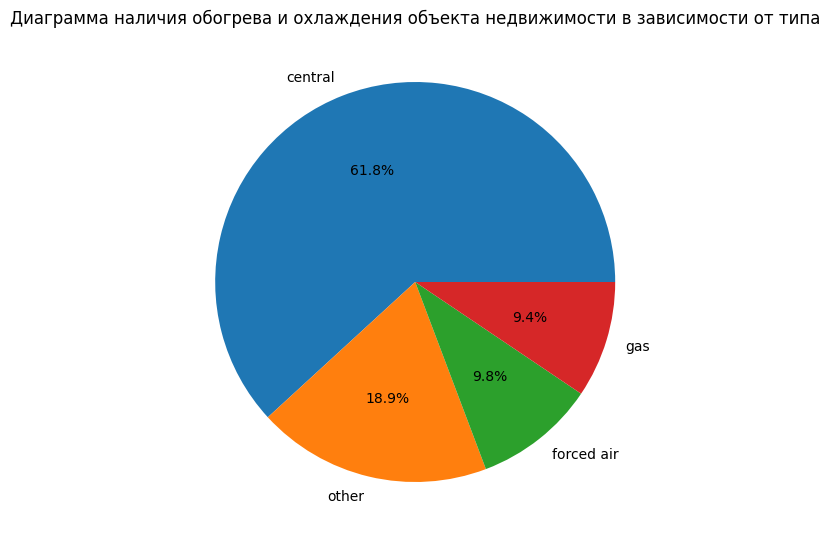

In [255]:
pie_data = df_temp_filtered['Heating_Cooling'].value_counts()

fig = plt.figure(figsize=(5,5))
axes = fig.add_axes([0,0,1,1])
axes.pie(
    pie_data,
    labels=pie_data.index,
    autopct='%.1f%%'
)
title= axes.set_title('Диаграмма наличия обогрева и охлаждения объекта недвижимости в зависимости от типа')

**Вывод**

*Наиболее распрастраненный тип обогрева\охлаждения после группировки central. 21.7% составляют пропуски в данных будем заполнять по медианному значению*

In [256]:
#Закодируем признак Parking установив 0 если данные отсутствуют и 1 при наличии
df_temp_filtered['Parking'] = df_temp_filtered['Parking'].apply(lambda x: 0 if x == '' else 1)

In [257]:
#Переведем признак lotsize(размер участка) в цифровой формат
df_temp_filtered['lotsize'] = df_temp_filtered['lotsize'].apply(lambda x: "".join(re.findall(r'\d+', str(x))))
df_temp_filtered['lotsize'] = df_temp_filtered['lotsize'].apply(lambda x: -1 if x == '' else x)
df_temp_filtered['lotsize'] = df_temp_filtered['lotsize'].apply(lambda x: int(x))
df_temp_filtered['lotsize'] = df_temp_filtered['lotsize'].replace({-1: np.nan})
#Сразу для лучшей визуализации удалим значительный выброс в признаке lotsize
mask_lotsize =  (df_temp_filtered.lotsize < 1000000) | (df_temp_filtered.lotsize.isna())
df_temp_filtered = df_temp_filtered[mask_lotsize]

#Переведем признак Price/sqft в цифровой формат
df_temp_filtered['Price/sqft'] = df_temp_filtered['Price/sqft'].apply(lambda x: "".join(re.findall(r'\d+', str(x))))
df_temp_filtered['Price/sqft'] = df_temp_filtered['Price/sqft'].apply(lambda x: -1 if x == '' else x)
df_temp_filtered['Price/sqft'] = df_temp_filtered['Price/sqft'].apply(lambda x: int(x))
df_temp_filtered['Price/sqft'] = df_temp_filtered['Price/sqft'].replace({-1: np.nan})

#Удалим признак homeFacts
df_temp_filtered.drop(['homeFacts'], axis=1, inplace=True)

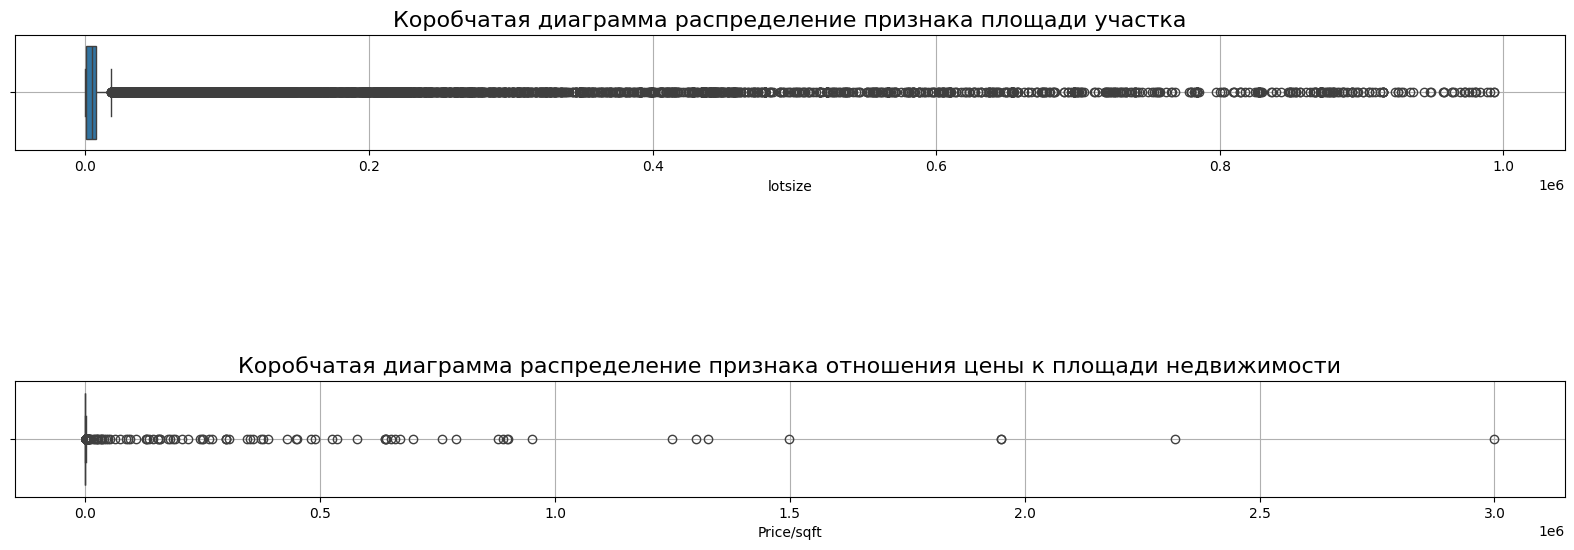

In [258]:
#Начертим коробчатые диаграмы вновь образованных признаков lotsize и Price/sqft, чтобы проверить наличие выбросов
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20,6))
plt.subplots_adjust(hspace=2, wspace=1) 
boxplot = sns.boxplot(
    data=df_temp_filtered,
    x='lotsize',
    orient='h',
    ax=axes[0]
);
boxplot.set_title('Коробчатая диаграмма распределение признака площади участка', fontsize=16);
boxplot.grid()
boxplot = sns.boxplot(
    data=df_temp_filtered,
    x='Price/sqft',
    orient='h',
    ax=axes[1]
);
boxplot.set_title('Коробчатая диаграмма распределение признака отношения цены к площади недвижимости', fontsize=16);
boxplot.grid()

**Выводы**

*Коробчатые диаграммы показывают наличие значительное количество выбросов в признаке lotsize. Поэтому признак подлежит удалению. В признаке Price/sqft выбросы находятся в диапазоне более 1000*

In [259]:
#Удалим выбросы в признаке Price/sqft
mask_Price_sqft = (df_temp_filtered['Price/sqft'] < 1000) | (df_temp_filtered['Price/sqft'].isna())
df_temp_filtered = df_temp_filtered[mask_Price_sqft]

#Удалим признак lotsize из-за очень большого наличия выбросов
df_temp_filtered.drop(['lotsize'], axis=1, inplace=True)

#Сбросим исходные индексы после удаления
df_temp_filtered = df_temp_filtered.reset_index(drop=True)

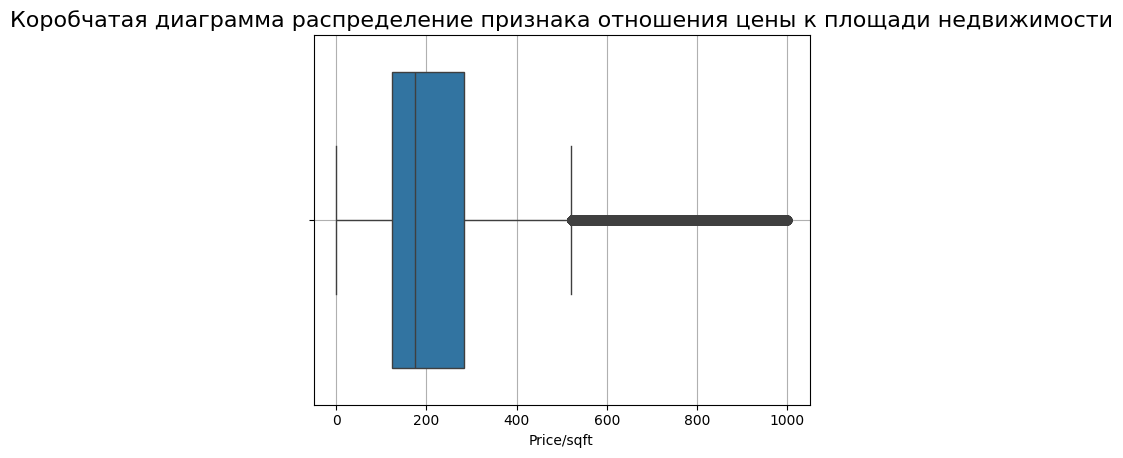

In [260]:
#Начертим график признака Price/sqft после удаления выбросов
boxplot = sns.boxplot(
    data=df_temp_filtered,
    x='Price/sqft',
    orient='h'
);
boxplot.set_title('Коробчатая диаграмма распределение признака отношения цены к площади недвижимости', fontsize=16);
boxplot.grid()

**Выводы**

*Коробчатая диаграмма показывает отсутствие выбросов в признаке Price/sqft*

In [261]:
def get_school_ratings(arg):
    '''Функция вычисления среднего рейтинга школ в районе расположения объекта недвижимости'''
    try:
        data = ast.literal_eval(arg)
        data = str(data).split(":")
        school_ratings = " ".join(re.findall(r'\d+', str(data[1])))
        list_school_ratings = [int(n) for n in set(school_ratings.split())]
        return round(sum(list_school_ratings)/len(list_school_ratings),1)        
  
    except ZeroDivisionError:
        return np.nan
        
df_temp_filtered['school_ratings'] = df_temp_filtered['schools'].apply(get_school_ratings)

In [262]:
def get_school_distance(arg):
    '''Функция вычисления среднего расстояния до школ в районе расположения объекта недвижимости'''
    try:
        data = ast.literal_eval(arg)
        data = str(data).split(":")
        school_ratings = " ".join(re.findall(r'\d+', str(data[3])))
        list_school_ratings = [int(n) for n in set(school_ratings.split())]
        return sum(list_school_ratings)/len(list_school_ratings)        
  
    except ZeroDivisionError:
        return np.nan
        
df_temp_filtered['school_distance'] = df_temp_filtered.schools.apply(get_school_distance)

In [263]:
#Удалим признак schools
df_temp_filtered.drop(['schools'], axis=1, inplace=True)

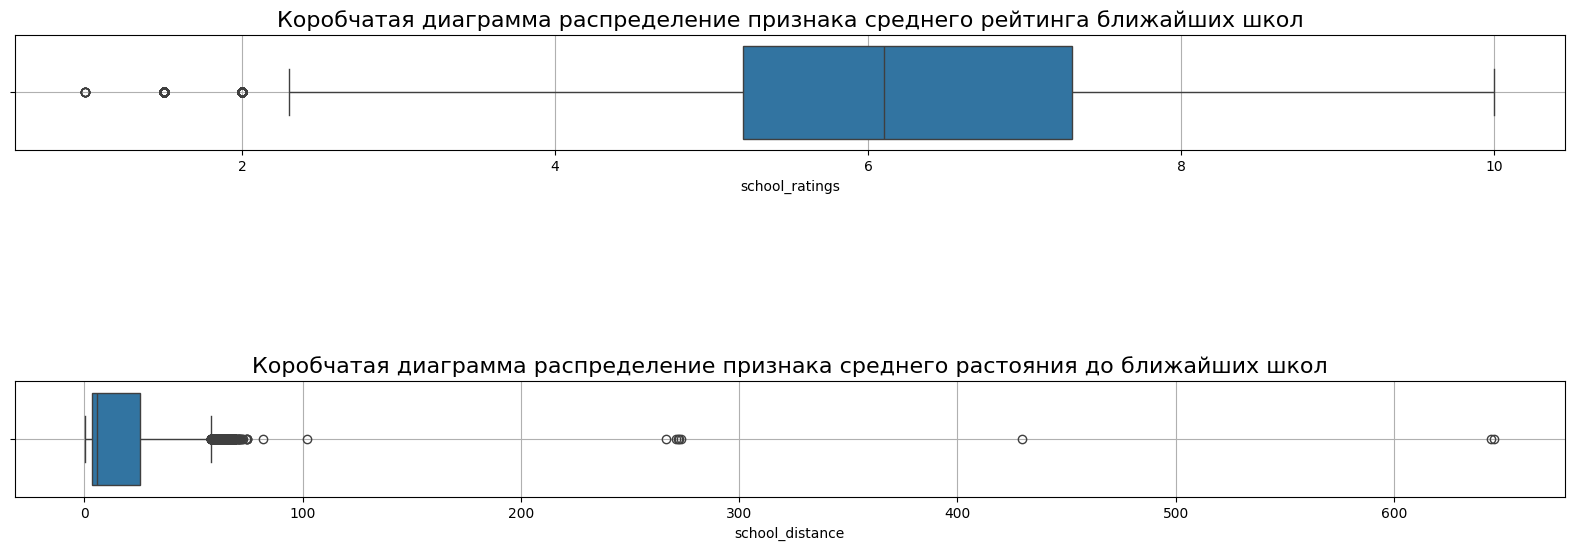

In [264]:
#Начертим коробчатые диаграмы вновь образованных признаков, чтобы проверить наличие выбросов
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20,6))
plt.subplots_adjust(hspace=2, wspace=1) 
boxplot = sns.boxplot(
    data=df_temp_filtered,
    x='school_ratings',
    orient='h',
    ax=axes[0]
)
boxplot.set_title('Коробчатая диаграмма распределение признака среднего рейтинга ближайших школ', fontsize=16);
boxplot.grid()
boxplot = sns.boxplot(
    data=df_temp_filtered,
    x='school_distance',
    orient='h',
    ax=axes[1]
);
boxplot.set_title('Коробчатая диаграмма распределение признака среднего растояния до ближайших школ', fontsize=16);
boxplot.grid()

**Выводы**

*Коробчатые диаграммы показывают отсутствие выбросов в признаке school_ratings и наличие выбросов в признаке school_distance превышающих на значение 65*

In [265]:
#Удалим выбросы в признаке school_distance
mask_school_distance = (df_temp_filtered['school_distance'] < 65) | (df_temp_filtered['school_distance'].isna())
df_temp_filtered = df_temp_filtered[mask_school_distance]

In [17]:
# Возможно скачать датасет c координатами города и объекта недвижимости. Для скачивания данных используйте gdown. 
#Скачиваем файл с данными по слудующей ссылке 'https://drive.google.com/file/d/15U8UlqUGYL0ebC9CeYi-Q87oLlNVpLZe/view?usp=sharing' с указанием id файла
file_url = 'https://drive.google.com/uc?export=download&id=15U8UlqUGYL0ebC9CeYi-Q87oLlNVpLZe'
# Скачиваем и присваиваем имемя файла переменной
data = 'data/df_decoded.csv'
gdown.download(file_url, data, quiet=False)
print(f"Файл скачан как: {data}")

df_decoded = pd.read_csv('data/df_decoded.csv', index_col=0)

Downloading...
From: https://drive.google.com/uc?id=15U8UlqUGYL0ebC9CeYi-Q87oLlNVpLZe
To: C:\Курс DS-3.0\IDE\Diploma_project\data\df_decoded.csv
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19.9M/19.9M [00:05<00:00, 3.91MB/s]


Файл скачан как: data/df_decoded.csv


In [267]:
#Объединим основной DataFrame с датасетом с координатами центра города и объекта недвижимости
df_temp_filtered = pd.concat(
[df_temp_filtered, df_decoded],
axis=1
)

In [268]:
def get_lat(arg):
    '''Функция выделения широты из общих координат и перевода в тип данных float'''
    try:
        return float(str(arg).split(',')[0])        
  
    except IndexError:
        return np.nan

def get_lng(arg):
    '''Функция определения долготы из общих координат и перевода в тип данных float'''
    try:
        return float(str(arg).split(',')[1])        
  
    except IndexError:
        return np.nan

#Воспользуемся признаками city_coordinates и address_coordinates, чтобы создать отдельные признаки широты и долготы с помощью функций  get_lat и get_lng
df_temp_filtered['lat_city'] = df_temp_filtered['city_coordinates'].apply(get_lat)
df_temp_filtered['lng_city'] = df_temp_filtered['city_coordinates'].apply(get_lng)
df_temp_filtered['lat_address'] = df_temp_filtered['address_coordinates'].apply(get_lat)
df_temp_filtered['lng_address'] = df_temp_filtered['address_coordinates'].apply(get_lng)

#Удалим ненужные признаки address_coordinates и city_coordinates
df_temp_filtered.drop(['address_coordinates', 'city_coordinates', 'street', 'city', 'zipcode'], axis=1, inplace=True)

In [287]:
df_temp_filtered = df_temp.copy()

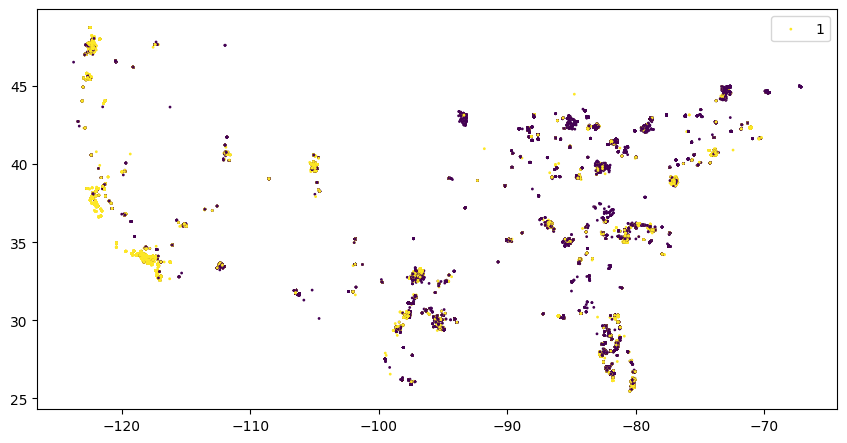

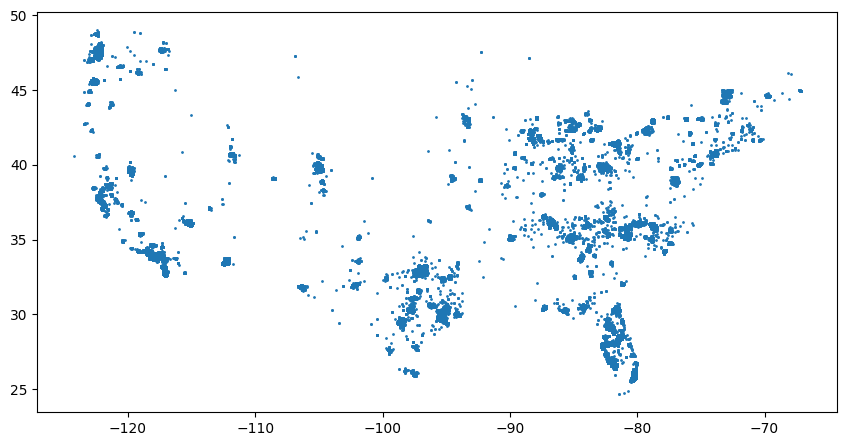

In [288]:
#Построим диаграммы рассеивания показывающие расположение городов с группировкой по медианной стоимости объектов недвижимости
data_cluster = df_temp_filtered.copy()
median_x = data_cluster['target'].median()
data_cluster['cluster'] = data_cluster['target'].apply(lambda x: 0 if x < median_x else 1)

city_lng_border = (data_cluster['lng_address'].min(), data_cluster['lng_address'].max())
city_lat_border = (data_cluster['lat_address'].min(), data_cluster['lat_address'].max())

df_temp_filtered_geo = data_cluster[['lng_city', 'lat_city','lng_address', 'lat_address', 'cluster']]

# Наденем на DataFrame маски
mask_lng_min_city = df_temp_filtered_geo['lng_city'] >= city_lng_border[0] 
mask_lng_max_city = df_temp_filtered_geo['lng_city'] <= city_lng_border[1]
mask_lat_min_city = df_temp_filtered_geo['lat_city'] >= city_lat_border[0] 
mask_lat_max_city = df_temp_filtered_geo['lat_city'] <= city_lat_border[1]

mask_lng_min_address = df_temp_filtered_geo['lng_address'] >= city_lng_border[0] 
mask_lng_max_address = df_temp_filtered_geo['lng_address'] <= city_lng_border[1]
mask_lat_min_address = df_temp_filtered_geo['lat_address'] >= city_lat_border[0] 
mask_lat_max_address = df_temp_filtered_geo['lat_address'] <= city_lat_border[1]

# Отфильтруем используя маски
data_cleaned_geo_filtered_city = df_temp_filtered_geo[((mask_lng_min_city & mask_lng_max_city) & (mask_lat_min_city & mask_lat_max_city))]
data_cleaned_geo_filtered_address = df_temp_filtered_geo[((mask_lng_min_address & mask_lng_max_address) & (mask_lat_min_address & mask_lat_max_address))]

# Построим диаграмму рассеяния иллюструющую географическое расположение городов с группировкой по медианной стоимостью недвижимости 
fig = plt.figure(figsize=(8, 4))
axes = fig.add_axes([0, 0, 1, 1])
axes.scatter(
    x=data_cleaned_geo_filtered_city['lng_city'], 
    y=data_cleaned_geo_filtered_city['lat_city'],
    c = data_cleaned_geo_filtered_city['cluster'],
    s=1
);
plt.legend(data_cleaned_geo_filtered_city['cluster'])
# Построим диаграмму рассеяния иллюструющую географического расположения точек объектов недвижимости
fig = plt.figure(figsize=(8, 4))
axes = fig.add_axes([0, 0, 1, 1])
axes.scatter(
    x=data_cleaned_geo_filtered_address['lng_address'], 
    y=data_cleaned_geo_filtered_address['lat_address'],
    s=1
);

**Вывод**

*Диаграммы рассеивания показывают, что объекты недвижимости с большей медианной стоимостью располагаются на побережье. Наблюдается незначительное количество объектов, расположенных далеко от населенных пунктов. На востоке медианная стоимость выше, чем на западе страны. При сравнении диаграмм наблюдается наличие выбросов. Удалим их после создания нового признака удаления объекта недвижимости от центра населенного пункта haversine_distance** 

In [311]:
#Напишем функции для определения расстояния между центром города и объектом недвижимости
def get_haversine_distance(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # радиус земли в километрах
    EARTH_RADIUS = 6371 
    # считаем кратчайшее расстояние h по формуле Хаверсина
    lat_delta = lat2 - lat1
    lng_delta = lng2 - lng1
    d = np.sin(lat_delta * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng_delta * 0.5) ** 2
    h = 2 * EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h


def add_geographical_features(df):
    '''функция принимает на вход таблицу с данными значений широты и долготы и возвращает обновленную таблицу с добавленными столбцами:
    - haversine_distance - расстояние Хаверсина'''
    df_copy = df.copy()
    df_copy['haversine_distance'] = df_copy.apply(lambda row: get_haversine_distance(row['lat_city'], row['lng_city'], row['lat_address'], row['lng_address']), axis=1)
    return df_copy

df_add_haversine_distance = add_geographical_features(df_temp_filtered)

#После определения расстония от центра города до объекта недвижимости удалим все признаки широты и долготы 
df_add_haversine_distance.drop(['lat_city',	'lng_city',	'lat_address',	'lng_address'], axis=1, inplace=True)

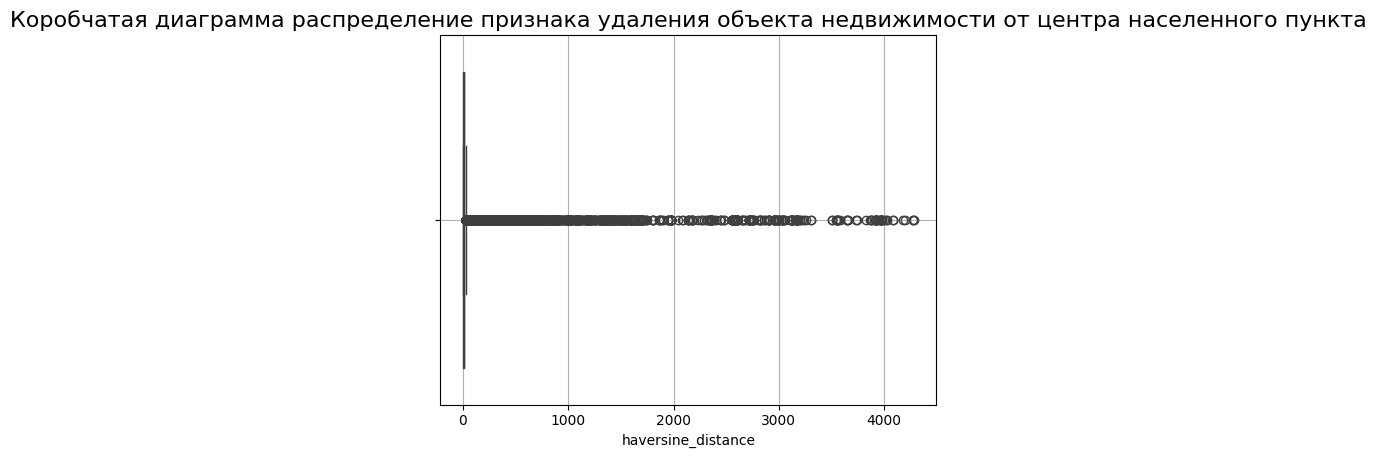

In [290]:
#Начертим коробчатые диаграмы вновь образованных признака haversine_distance, чтобы проверить наличие выбросов
boxplot = sns.boxplot(
    data=df_add_haversine_distance,
    x='haversine_distance',
    orient='h'
);
boxplot.set_title('Коробчатая диаграмма распределение признака удаления объекта недвижимости от центра населенного пункта', fontsize=16);
boxplot.grid()

**Вывод**

*Коробчатая диаграмма показывает наличие выбросов на значениях haversine_distance более 500. Очистим от выбросов*

In [318]:
#Удалим выбросы в признаке haversine_distance
mask_haversine_distance = (df_add_haversine_distance['haversine_distance'] < 500) | (df_add_haversine_distance['haversine_distance'].isna())
df_add_haversine_distance = df_add_haversine_distance[mask_haversine_distance]

#Сбросим исходные индексы после удаления
df_temp_filtered = df_add_haversine_distance.copy()
df_temp_filtered = df_temp_filtered.reset_index(drop=True)

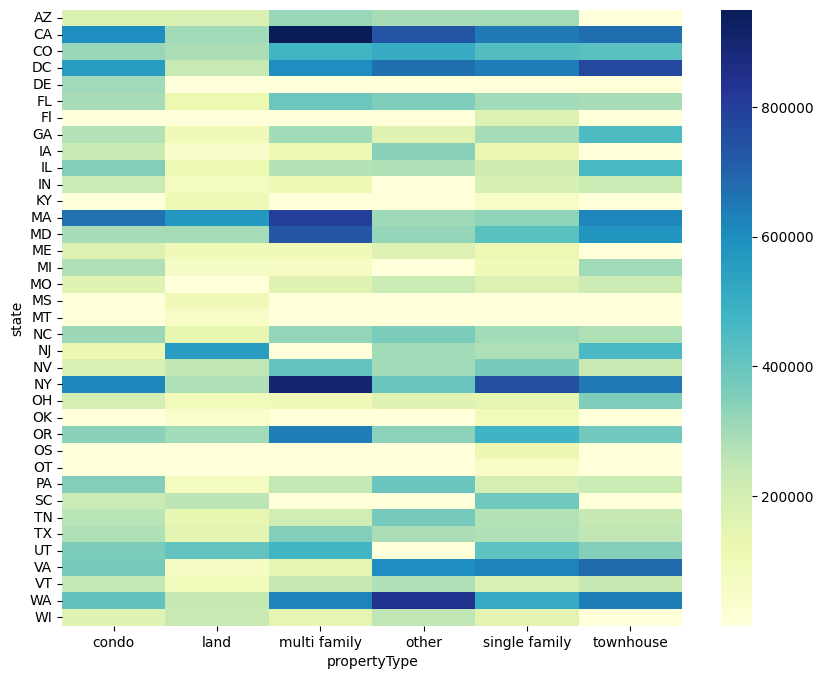

In [330]:
data = df_temp_filtered.copy()
data.target = data.target.apply(lambda x: math.exp(x)-1)
data = data.pivot_table(
values='target',
index='state',
columns='propertyType',
aggfunc='median',
fill_value=10
)
fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(data=data, cmap='YlGnBu')
plt.gcf().set_size_inches(10, 8)
plt.show()
heatmap.set_title('Тепловая карта медианной стоимости недвижимости в зависимости по штатам', fontsize=16);

**Вывод:**

*Тепловая карта показывает, что наиболее дорогостоящий тип недвижимости multi family. Наиболее дорогая недвижимость располагается в штатах CA, CO, DC, NY, WA*

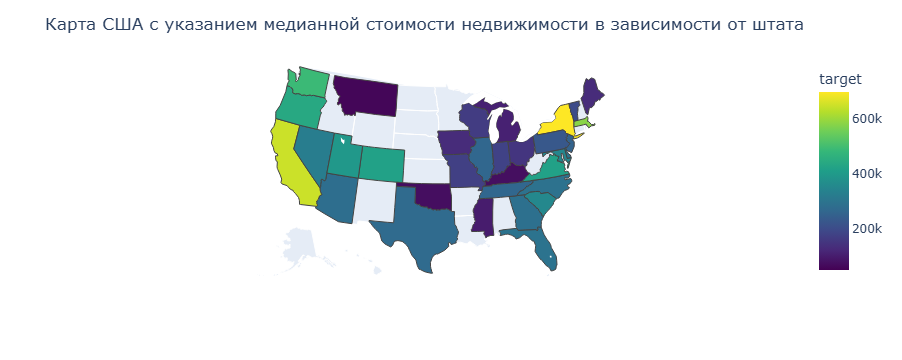

In [7]:
#Построим карту США с указанием медианной стоимости недвижимости по штатам
df_temp = df_temp_filtered.copy()

#Переведем целевой признак target из значений натурального логарифма в изначальный $
df_temp['target'] = df_temp['target'].apply(lambda x: math.exp(x))

#Сгруппируем по признакам state и target, с расчетом медианной стоимости недвижимости
data = pd.DataFrame(df_temp.groupby(by=['state'])['target'].median())

# Построим карту распределления стоимости недвижимости в зависимости от штата
fig = px.choropleth(data, locations=data.index, locationmode="USA-states", 
                    color='target', scope="usa",
                    color_continuous_scale="Viridis")
fig.update_layout(title_text="Карта США с указанием медианной стоимости недвижимости в зависимости от штата")
fig.show()

**Вывод**

*Тепловая картограмма показывает, что наиболее высокая медианная стоимость недвижимости наблюдается в штатах СА-Калифорния и NY-Нью-Йорк. Медианная стоимость составляет более 600000$*

In [2]:
# Сохраним DataFrame
#df_temp_filtered.to_csv('data/df_temp_filtered.csv')
#df_temp_filtered = pd.read_csv('data/df_temp_filtered.csv', index_col=0)

### 4.2. Заполняем пропуски во вновь созданных признаках 

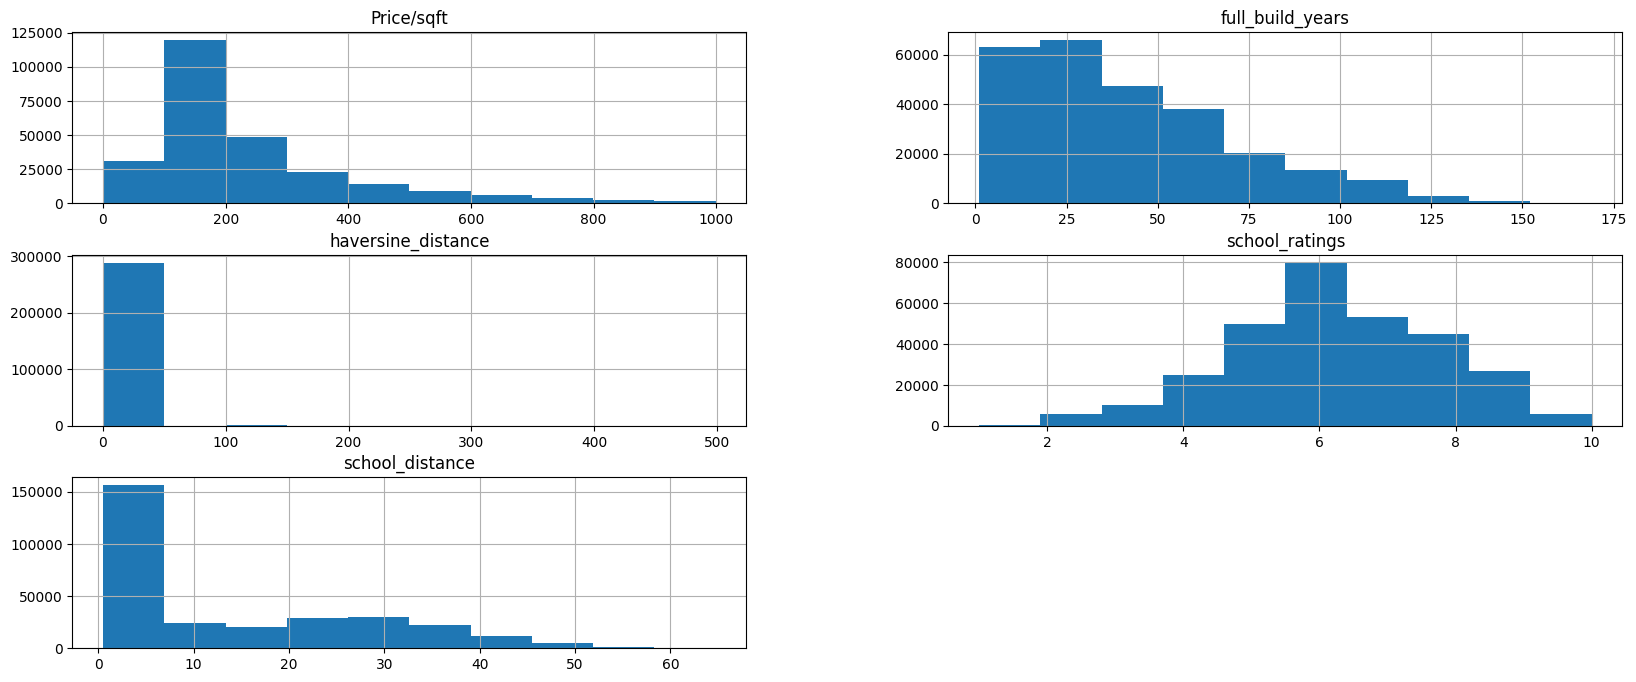

In [4]:
# Начертим гистограмму признаков с пропущенными значениями для вновь созданных признаков
cols_null_percent = df_temp_filtered.isnull().mean()*100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
cols = cols_with_null.index
df_temp_filtered[cols].hist(figsize=(20, 8));

**Выводы:**

- *Для распределений, похожих на логнормальное, где пик близ нуля, предпочтительнее использовать медианное значение. Это признак признаки Price/sqft, school_distance, full_build_years, school_distance и haversine_distance.*
- *Для распределений, похожих на нормальное признак school_ratings предпочтительнее использовать среднее значение*
- *Категориальные признак Heating_Cooling заполним модальным значением.*

In [5]:
#создаем копию исходной таблицы
fill_data = df_temp_filtered.copy()

#создаем словарь имя столбца: число(признак) на который надо заменить пропуски:
values = {
    'Price/sqft': fill_data['Price/sqft'].median(),
    'school_distance': round(fill_data['school_distance'].median(),2),
    'full_build_years': fill_data['full_build_years'].median(),
    'school_ratings': round(fill_data['school_ratings'].mean()),
    'Heating_Cooling': fill_data['Heating_Cooling'].mode()[0],
    'haversine_distance': round(fill_data['school_distance'].median(),2)
}
#заполняем пропуски в соответствии с заявленным словарем:
fill_data = fill_data.fillna(values)
#выводим результирующую долю пропусков:
fill_data.isnull().mean()

status                0.0
propertyType          0.0
baths                 0.0
sqft                  0.0
beds                  0.0
state                 0.0
stories               0.0
target                0.0
MLS                   0.0
Parking               0.0
Price/sqft            0.0
full_build_years      0.0
Heating_Cooling       0.0
school_ratings        0.0
school_distance       0.0
haversine_distance    0.0
dtype: float64

In [6]:
#Еще раз произведем очистку от дубликатов, т.к было заново создано большое кол-во признаков с заполнением пустых значений
data_cleaned_duplicates = fill_data.copy()

#Создадим маску для поиска дубликатов с помощью функции duplicated()
mask = data_cleaned_duplicates.duplicated(subset=data_cleaned_duplicates.columns)
print('Дубликатов в данных:', data_cleaned_duplicates[mask].shape[0])

Дубликатов в данных: 1174


In [7]:
#Удалим дубликаты из DataFrame
df_temp_filtered = data_cleaned_duplicates.drop_duplicates()

In [8]:
# Сохраним полученный DataFrame
#df_cleaned_eda = df_temp_filtered.copy()
#df_cleaned_eda.to_csv('data/df_cleaned_eda.csv')
#df_temp_filtered = pd.read_csv('data/df_cleaned_eda.csv', index_col=0)

### 4.3. Создаем новые признаки с помощью автоматических методов EDA

In [9]:
df_temp_filtered = df_cleaned_eda.copy()

#Произведем ОДНОКРАТНОЕ КОДИРОВАНИЕ ONE-HOT ENCODING признаков status, propertyType, Heating_Cooling
encoder = ce.OneHotEncoder(cols=['status','propertyType', 'Heating_Cooling'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(df_temp_filtered[['status','propertyType', 'Heating_Cooling']])
df_temp_filtered = pd.concat([df_temp_filtered, type_bin], axis=1)

#Удалим категориальный признак status
df_temp_filtered.drop(['status','propertyType', 'Heating_Cooling'], axis=1, inplace=True)

In [10]:
#Произведем ДВОИЧНОЕ КОДИРОВАНИЕ BinaryEncoder для признака state

bin_encoder = ce.BinaryEncoder(cols=['state']) # указываем столбец для кодирования
type_bin = bin_encoder.fit_transform(df_temp_filtered['state'])
df_temp_filtered = pd.concat([df_temp_filtered, type_bin], axis=1)

#Удалим категориальный признак propertyType
df_temp_filtered.drop(['state'], axis=1, inplace=True)

In [3]:
#Сохраним преобразованный файл
#df_encoded = df_temp_filtered.copy()
#df_encoded.to_csv('data/df_encoded.csv')
#df_encoded = pd.read_csv('data/df_encoded.csv', index_col=0)

###  4.4. Произведем преобразование и отбор признаков

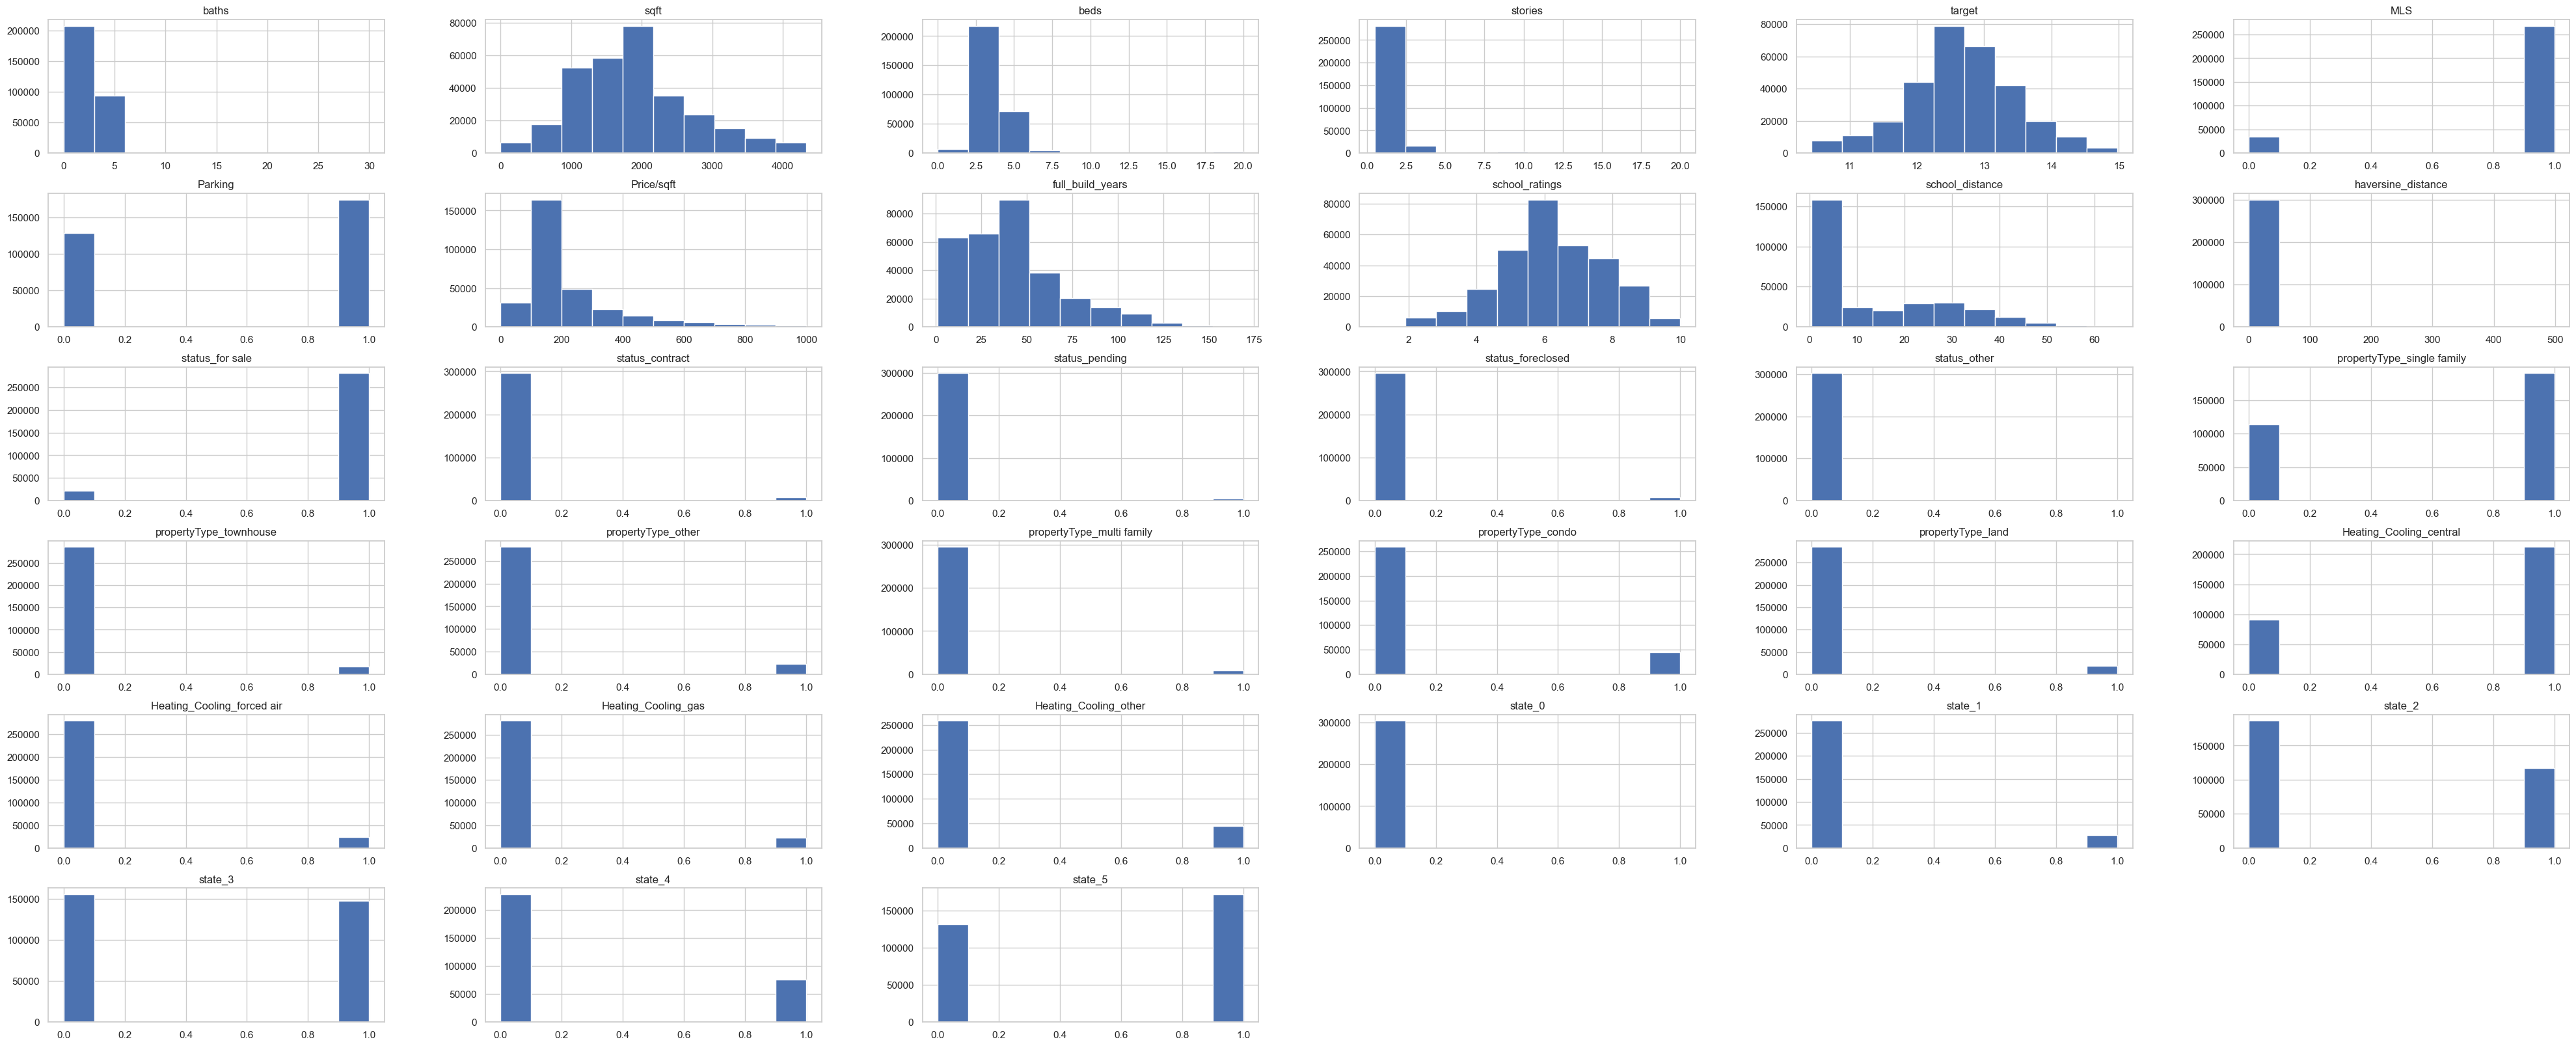

In [114]:
df_temp_filtered = df_encoded.copy()

# Построим гистограмму для визуальной оценки признаков на нормальность
df_temp_filtered.hist(figsize=(50, 20));

**Вывод**

*Гистограммы показывают, что только признаки target, sqft и school_rating распределены приблизительно по нормальному закону. Остальные признаки не распределены нормально*

#### Тест Д’Агостино на нормальность

In [28]:
from scipy.stats import normaltest

alpha = 0.05
H0 = 'распределены нормально'
Ha = 'не распределены нормально (мы отвергаем H0)'

for col in df_temp_filtered.columns:
    _, p = normaltest(df_temp_filtered[col])
#normaltest возвращает двустороннюю вероятность для проверки гипотезы

    print('p=%.3f' % p)

# Интерпретация 

    if p > alpha/2:
        print(f'Данные {col} {H0}')
    else:
        print(f'Данные {col} {Ha}')

p=0.000
Данные baths не распределены нормально (мы отвергаем H0)
p=0.000
Данные sqft не распределены нормально (мы отвергаем H0)
p=0.000
Данные beds не распределены нормально (мы отвергаем H0)
p=0.000
Данные stories не распределены нормально (мы отвергаем H0)
p=0.000
Данные target не распределены нормально (мы отвергаем H0)
p=0.000
Данные MLS не распределены нормально (мы отвергаем H0)
p=0.000
Данные Parking не распределены нормально (мы отвергаем H0)
p=0.000
Данные Price/sqft не распределены нормально (мы отвергаем H0)
p=0.000
Данные full_build_years не распределены нормально (мы отвергаем H0)
p=0.000
Данные school_ratings не распределены нормально (мы отвергаем H0)
p=0.000
Данные school_distance не распределены нормально (мы отвергаем H0)
p=0.000
Данные haversine_distance не распределены нормально (мы отвергаем H0)
p=0.000
Данные status_for sale не распределены нормально (мы отвергаем H0)
p=0.000
Данные status_contract не распределены нормально (мы отвергаем H0)
p=0.000
Данные status

**Вывод:**

*Более точный тест Д’Агостино говорит, что данные во всех признаках не распределены нормально, а значит требуется нормализация признаков. Т.к. мы производили очистку от выбросов, то будем использовать MinMaxScaler. Далее произведем анализ признаков на мультиколлинеарность*

In [5]:
# непрерывные признаки
num_cols = ['baths', 'sqft', 'beds', 'stories', 'Price/sqft', 'full_build_years', 'school_ratings', 
            'school_distance', 'haversine_distance', 'target']

# категориальные признаки
cat_cols = ['MLS', 'Parking', 'status_for sale', 'status_contract',
       'status_pending', 'status_foreclosed', 'status_other',
       'propertyType_single family', 'propertyType_townhouse',
       'propertyType_other', 'propertyType_multi family', 'propertyType_condo',
       'propertyType_land', 'Heating_Cooling_central',
       'Heating_Cooling_forced air', 'Heating_Cooling_gas',
       'Heating_Cooling_other', 'state_0', 'state_1', 'state_2', 'state_3',
       'state_4', 'state_5']

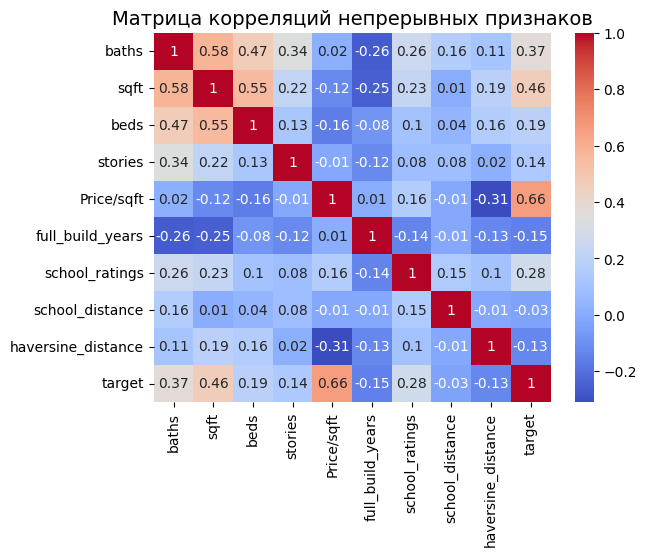

In [116]:
# Для непрерывных признаков построим матрицу корреляций методом Спирмена, т.к признаки не распределены нормально
heatmap = sns.heatmap(round(df_temp_filtered[num_cols].corr(method='spearman'), 2), annot = True, cmap= 'coolwarm')
heatmap.set_title('Матрица корреляций непрерывных признаков', fontsize=14);

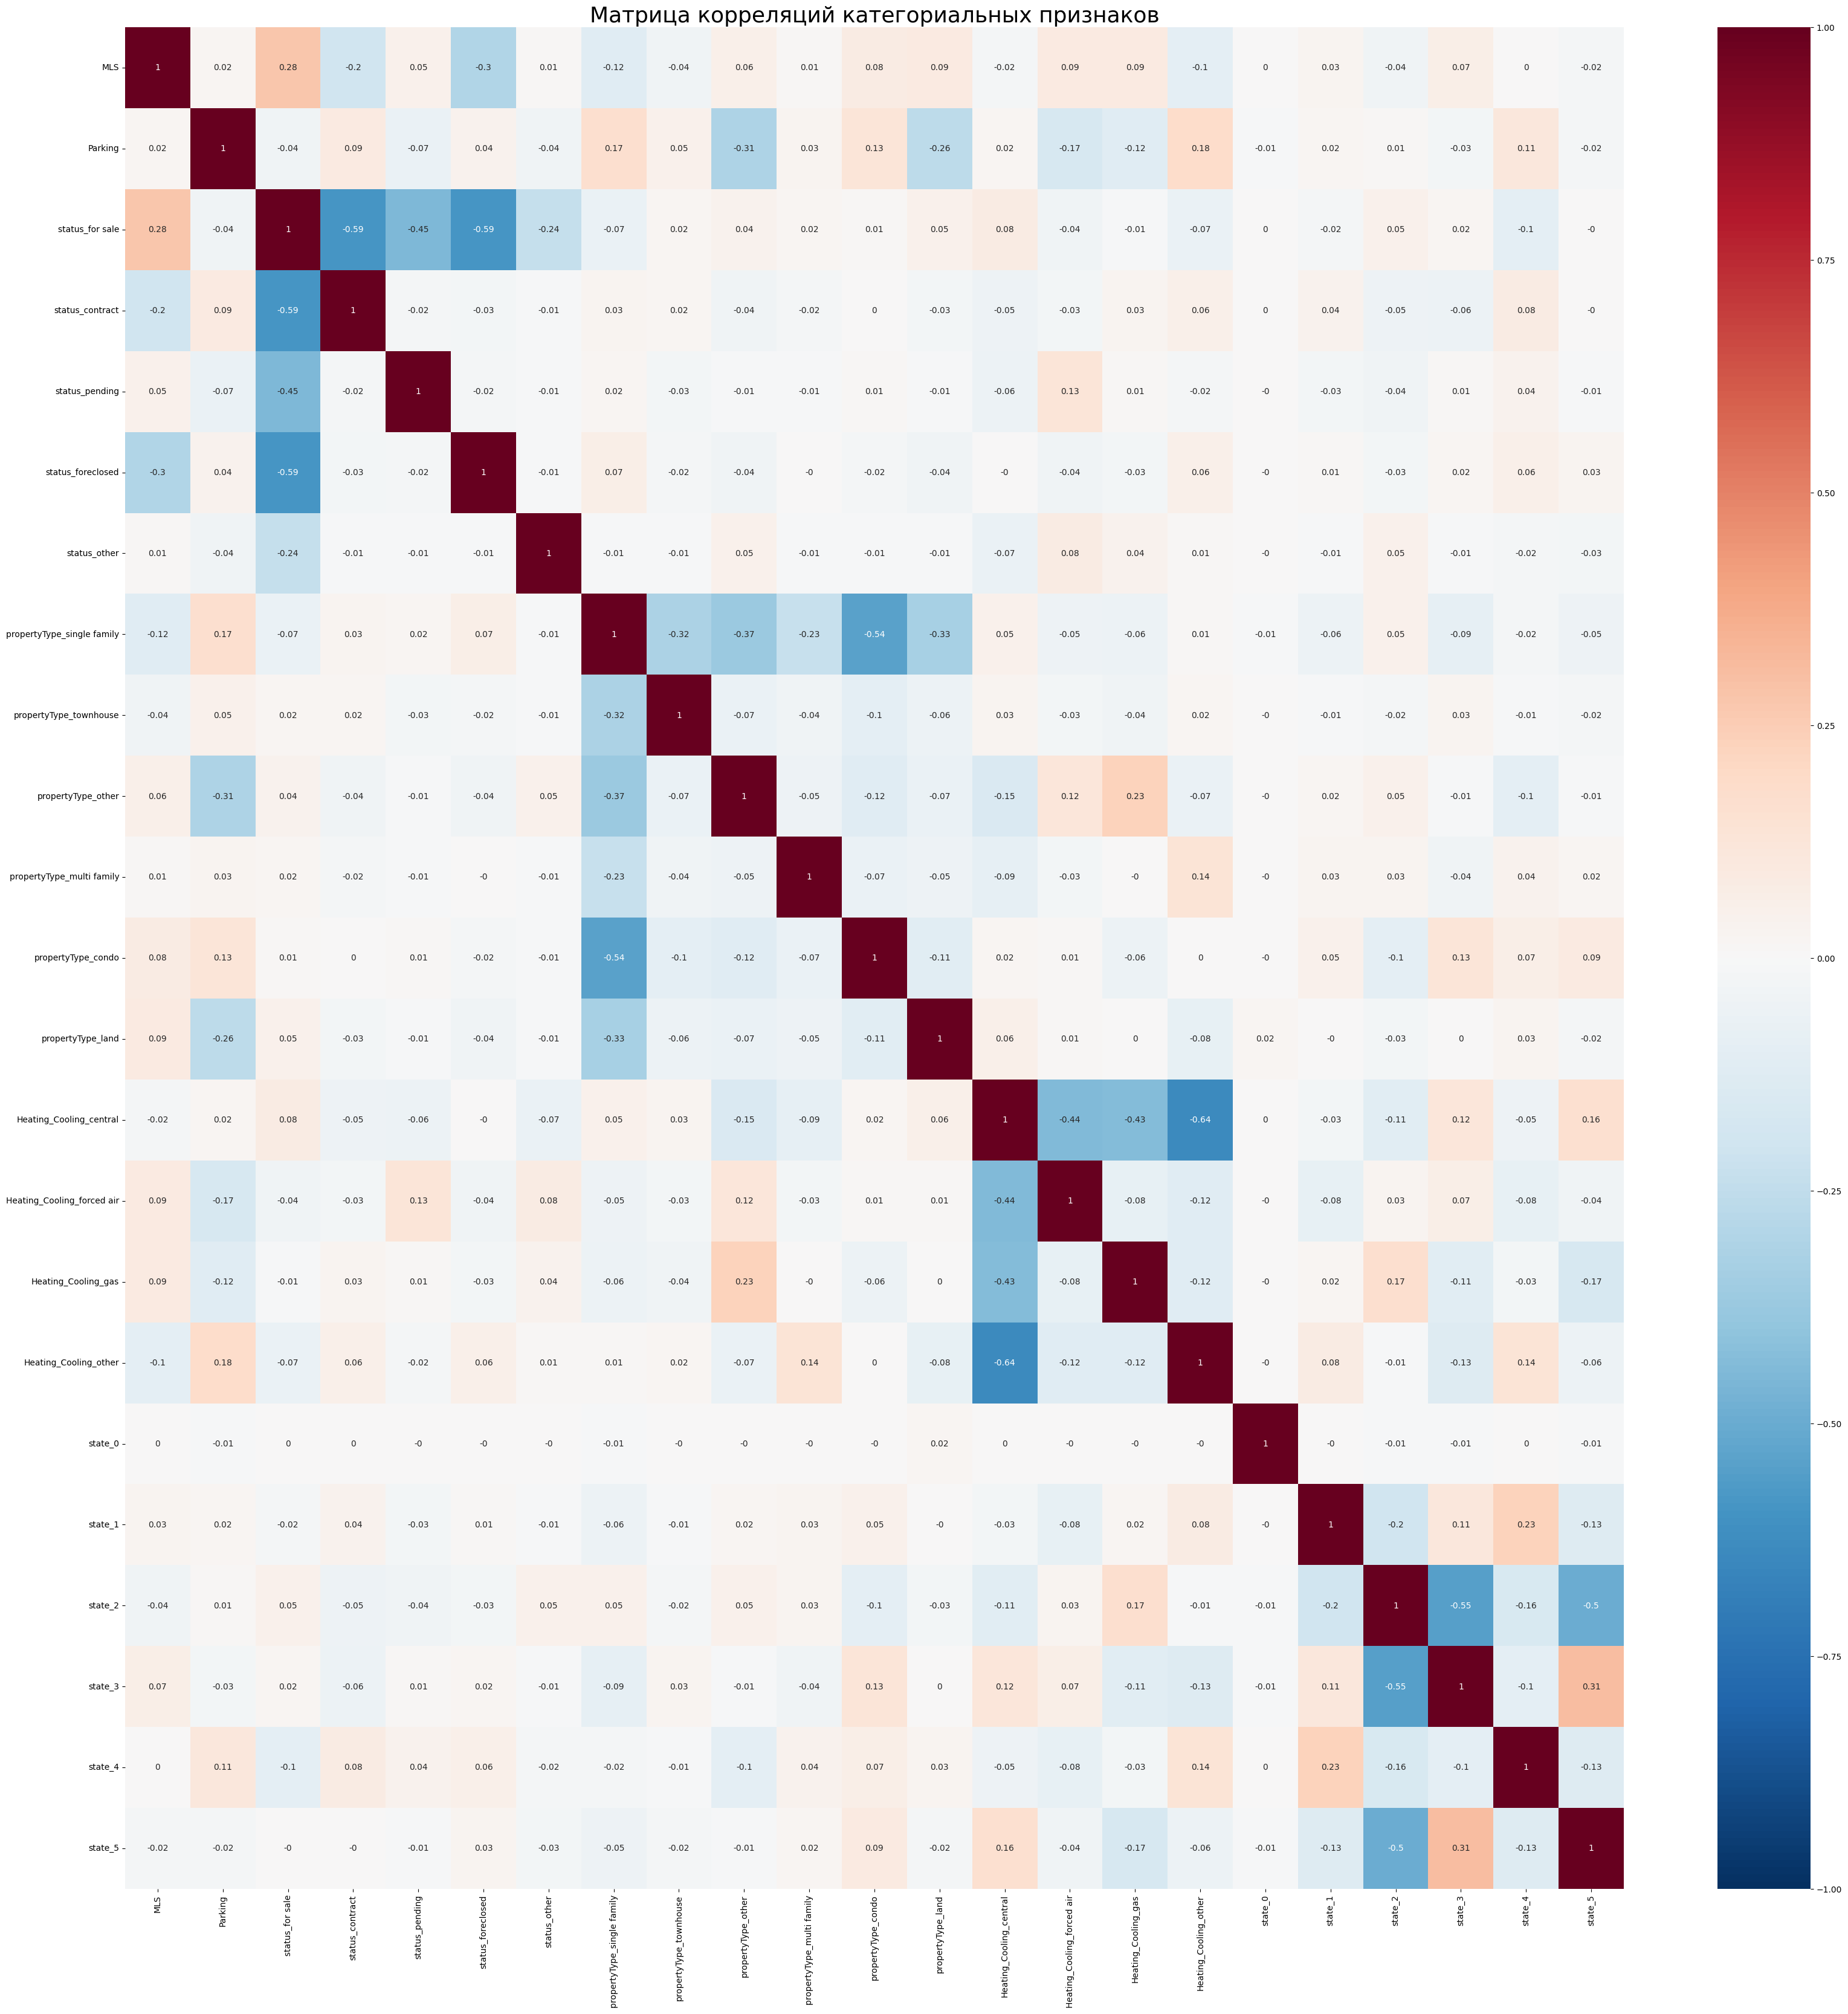

In [91]:
# Для категориальных признаков построим матрицу корреляций методом Спирмена, т.к признаки не распределены нормально
plt.figure(figsize=(40,40))
corr = round(df_temp_filtered[cat_cols].corr(method='spearman'), 2)
heatmap = sns.heatmap(corr, cmap=sns.color_palette("RdBu_r", 1000), vmin=-1, center=0, annot=True)
heatmap.set_title('Матрица корреляций категориальных признаков', fontsize=26);

**Вывод:**

*Матрицы корреляции непрерывных и категориальных признаков показывают отсутствие мультиколлинеарности между признаками, т.к. коэффициент корреляции не превышает 0.7. Признак Price/sqft имеет значительную корреляцию  с целевым признаком и в нем содержится информация о целевом признаке. Необходимо удаление данного признака*

In [6]:
df_temp_filtered.drop('Price/sqft', axis=1, inplace=True)

<Axes: title={'center': 'График оценки значимости категориальных признаков для целевой переменной — стоимость объекта недвижимости'}>

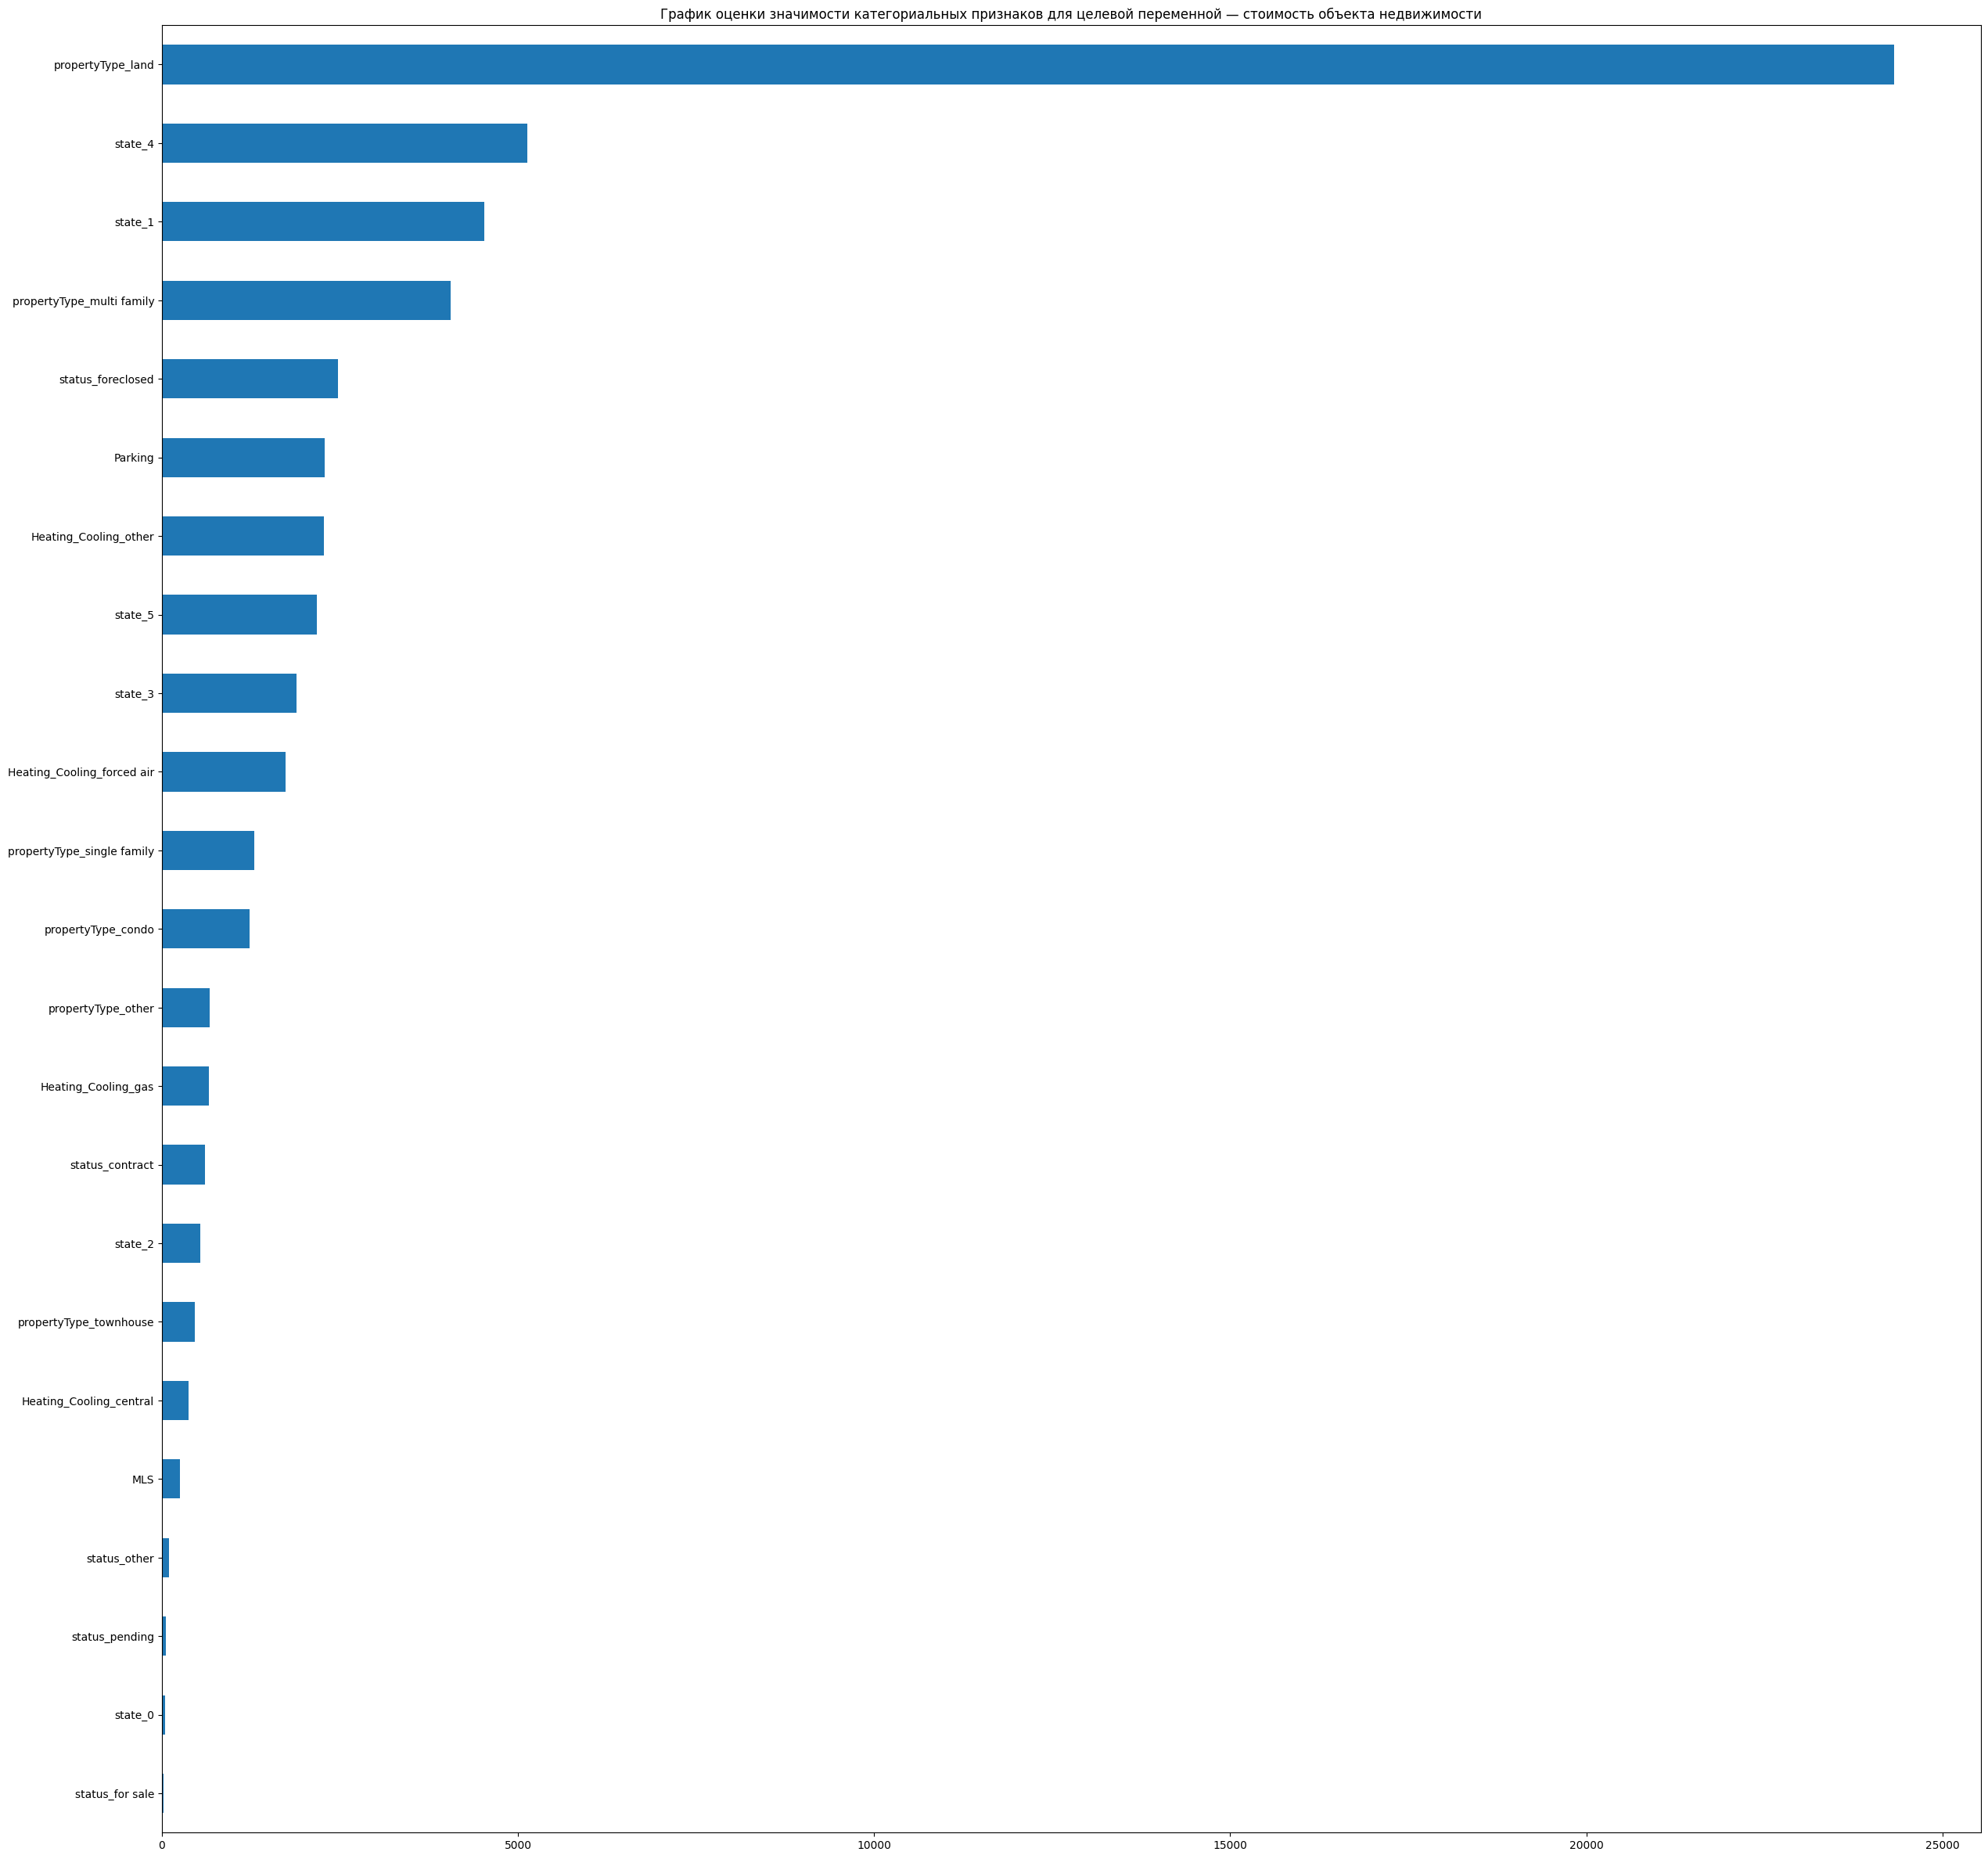

In [7]:
# Для категориальных признаков используем непараметрический тест хи-квадрат, т.к данные не распределены нормально

X = df_temp_filtered.drop(['target'], axis = 1)  
y = df_temp_filtered['target'] 

from sklearn.feature_selection import chi2 # хи-квадрат

plt.figure(figsize=(30,30))
imp_cat = pd.Series(chi2(X[cat_cols], y.astype('int'))[0], index=cat_cols)
imp_cat.sort_values(inplace = True)
imp_cat.plot(kind = 'barh', title='График оценки значимости категориальных признаков для целевой переменной — стоимость объекта недвижимости')

**Вывод:**

*Согласно тесту хи-квадрат, признак 'status_for_sale' может быть удален, т.к. он почти не влияет на целевую переменную. Пока не будем удалять этот признак.*

In [8]:
# Обновим список непрерывных признаков
num_cols_f_classif = ['baths', 'sqft', 'beds', 'stories', 'full_build_years', 'school_ratings', 
            'school_distance', 'haversine_distance']

<Axes: title={'center': 'График оценки значимости непрерывных признаков для целевой переменной — стоимость недвижимости'}>

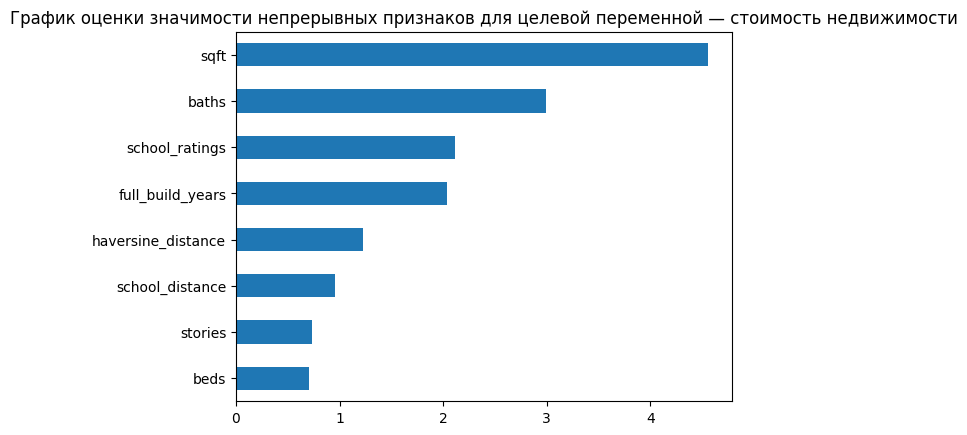

In [14]:
#Для непрерывных признаков используем тест ANOVA F-value
from sklearn.feature_selection import f_classif

imp_num = pd.Series(f_classif(X[num_cols_f_classif], y)[0], index = num_cols_f_classif)
imp_num.sort_values(inplace = True)
imp_num.plot(kind = 'barh', title='График оценки значимости непрерывных признаков для целевой переменной — стоимость недвижимости')

**Вывод:**

*Согласно тесту ANOVA F-value, удаление признаков не требуется*

In [9]:
#Создадим список отобранных с помощью тестов хи-квадрат и  ANOVA F-value признаков для дальнейшего сравнения
cols_updated = ['baths', 'sqft', 'beds', 'stories', 'full_build_years', 'school_ratings', 'school_distance',
                'haversine_distance', 'MLS', 'Parking', 'status_contract', 'status_pending', 'status_foreclosed', 
                'status_other', 'propertyType_single family', 'propertyType_townhouse', 'propertyType_other', 'propertyType_multi family',
                'propertyType_condo', 'propertyType_land', 'Heating_Cooling_central', 'Heating_Cooling_forced air', 'Heating_Cooling_gas', 
                'Heating_Cooling_other', 'state_0', 'state_1', 'state_2', 'state_3', 'state_4', 'state_5']

In [19]:
#С помощью SelectKBest отберем 25 признаков, наилучшим образом подходящих для предсказания целевой переменной в логарифмическом масштабе
from sklearn.feature_selection import SelectKBest, f_regression

# С помощью SelectKBest отберем 25 признаков
selector = SelectKBest(score_func=f_regression, k=25)
X_selected = selector.fit_transform(X, y)

selected_features = selector.get_feature_names_out()

# Выведем на экран полученые признаки
print("Selected Features:", selected_features)

# Сделаем Датафрейм с выбранными признаками
df_SelectKBest = pd.DataFrame(X_selected, columns=selected_features)

Selected Features: ['baths' 'sqft' 'beds' 'stories' 'MLS' 'Parking' 'full_build_years'
 'school_ratings' 'school_distance' 'haversine_distance' 'status_for sale'
 'status_contract' 'status_foreclosed' 'propertyType_single family'
 'propertyType_other' 'propertyType_multi family' 'propertyType_condo'
 'propertyType_land' 'Heating_Cooling_central'
 'Heating_Cooling_forced air' 'Heating_Cooling_other' 'state_1' 'state_3'
 'state_4' 'state_5']


**Вывод:**

*Данные тестов chi2, ANOVA F-value и SelectKBest расходятся. Дальнейшее иследование будем выполнять на двух группах признаков. В одной группе будут признаки отобранные с помощью методов chi2 и ANOVA F-value, а в другой признаки отобранные методом SelectKBest*

## 5. Моделирование. Решение задачи регрессии

### 5.1.1. Решение задачи регрессии: Линейная регрессия (LinearRegression)

In [21]:
# Разбиваем выборку на обучающую и валидационную в соотношении 60/40:
X_train, X_valid, y_train_log, y_valid_log = model_selection.train_test_split(
    X, y, 
    test_size=0.4, 
    random_state=42
)

In [12]:
#Производим преобразование признаков с помощью MinMaxScaler и обучим модель методом линейной регресии для двух групп признаков
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
#from sklearn.compose import make_column_transformer

pipeline = Pipeline([('scaler', MinMaxScaler()), ('lr', LinearRegression())])

**В качестве метрики качества** будем использовать метрики **Средняя абсолютная ошибка в процентах — MAPE (Mean Absolute
Percent Error):** $$\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$
MAPE метрика помогает абстрагироваться от конкретных чисел и оценить абсолютную ошибку в процентах. Ее легко интерпретировать. Используется в задачах, где неизвестно, какое значение метрики считать приемлемым. Лучше использовать в паре с медианной абсолютной ошибкой (MeAE - median_absolute_error), чтобы знать абсолютную ошибку и её значение в процентах.  
Дополнительно будем использовать метрику RMSLE. Используется в задачах, где критически важны большие ошибки. **RMSLE (Root Mean Squared Log Error)**, которая вычисляется как:$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(log(y_i+1)-log(\hat{y_i}+1))^2},$$
где:
* $y_i$ - истинная стоимость i-го объекта недвижимости (target)
* $\hat{y_i}$- предсказанная моделью стоимость i-го объекта недвижимости.
* Заметим, что логарифмирование целевого признака мы уже провели заранее, поэтому нам будет достаточно вычислить метрику RMSE для модели, обученной прогнозировать стоимость объекта недвижимости в логарифмическом масштабе:
$$z_i=log(y_i+1),$$
$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(z_i-\hat{z_i})^2}=\sqrt{MSE(z_i,\hat{z_i})}$$

В конце вычислим MAE в той модели, которая покажет максимальное качество MAPE и RMSLE с переводом обратно с значений натурального логарифма в $

In [13]:
# Рассчитываем метрику MAPE на тренировочной выборке и на валидационной выборке по признакам выбраным ручным поиском
pipeline.fit(X_train[cols_updated], y_train_log)
y_pred_train = pipeline.predict(X_train[cols_updated])
y_pred_valid = pipeline.predict(X_valid[cols_updated])


# Рассчитываем метрику MAPE и RMSLE на тренировочной выборке
print('MAPE score хи-квадрат и ANOVA F-value:', round(metrics.mean_absolute_percentage_error(y_train_log, y_pred_train), 3))
print('RMSLE score хи-квадрат и ANOVA F-value: {:.3f}'.format((metrics.mean_squared_error(y_train_log, y_pred_train)**0.5)))

# Рассчитываем метрику MAPE и RMSLE на валидационной выборке
print('MAPE score хи-квадрат и ANOVA F-value :', round(metrics.mean_absolute_percentage_error(y_valid_log, y_pred_valid), 3))
print('RMSLE score хи-квадрат и ANOVA F-value: {:.3f}'.format((metrics.mean_squared_error(y_valid_log, y_pred_valid)**0.5)))

MAPE score хи-квадрат и ANOVA F-value: 0.038
RMSLE score хи-квадрат и ANOVA F-value: 0.635
MAPE score хи-квадрат и ANOVA F-value : 0.038
RMSLE score хи-квадрат и ANOVA F-value: 0.636


In [22]:
# Рассчитываем метрику MAPE  и RMSLE на тренировочной выборке и на валидационной выборке по признакам выбраным с помощью SelectKBest
pipeline.fit(X_train[selected_features], y_train_log)
y_pred_train = pipeline.predict(X_train[selected_features])
y_pred_valid = pipeline.predict(X_valid[selected_features])

print('MAPE score SelectKBest:', round(metrics.mean_absolute_percentage_error(y_train_log, y_pred_train), 3))
print('RMSLE score SelectKBest: {:.3f}'.format((metrics.mean_squared_error(y_train_log, y_pred_train)**0.5)))

print('MAPE score SelectKBest:', round(metrics.mean_absolute_percentage_error(y_valid_log, y_pred_valid), 3))
print('RMSLE score SelectKBest: {:.3f}'.format((metrics.mean_squared_error(y_valid_log, y_pred_valid)**0.5)))

MAPE score SelectKBest: 0.038
RMSLE score SelectKBest: 0.635
MAPE score SelectKBest: 0.038
RMSLE score SelectKBest: 0.636


**Вывод:**

*Значение метрики MAPE при использовании линейной регрессии 0.032 оказалось достаточно приемлиемым. Значит качественно была произведена предобработка данных. Качество на тренировочной и валидационой выборках показали очень близкие значения, значит переобучение отсутствует. Оптимальные признаки полученные с помощью SelectKBest, показали аналогичные значение метрики MAPE, что с помощью тестов хи-квадрат и ANOVA F-value. Далее будем повышать использовать группу признаков отобранных методом SelectKBest, т.к количество признаков отобранное этим способом значительно меньше при неизменном качестве*

In [23]:
# инициализируем нормализатор MinMaxScaler
scaler = MinMaxScaler()

# обучаем нормализатора на тренировочной выборке
scaler.fit(X_train[selected_features])

# кодируем исходный датасет для обучающей и валидационной выборках 
X_train_MinMaxScaler = scaler.transform(X_train[selected_features])
X_valid_MinMaxScaler = scaler.transform(X_valid[selected_features])

# Преобразуем промежуточный датасет в полноценный датафрейм на тренировочной и валидационной выборках
df_X_train_MinMaxScaler = pd.DataFrame(X_train_MinMaxScaler, columns=selected_features)
df_X_valid_MinMaxScaler = pd.DataFrame(X_valid_MinMaxScaler, columns=selected_features)

### 5.1.2. Решение задачи регрессии: Полиномиальная регрессия (Polynomial Regression)

In [17]:
#Создаём генератор полиномиальных признаков
poly = preprocessing.PolynomialFeatures(degree=2, include_bias=False)
poly.fit(df_X_train_MinMaxScaler)
#Генерируем полиномиальные признаки для тренировочной выборки
X_train_poly = poly.transform(df_X_train_MinMaxScaler)
#Генерируем полиномиальные признаки для тестовой выборки
X_valid_poly = poly.transform(df_X_valid_MinMaxScaler)
#Создаём объект класса линейной регрессии
lr_model_poly = linear_model.LinearRegression()
#Обучаем модель по МНК
lr_model_poly.fit(X_train_poly, y_train_log)
#Делаем предсказание для тренировочной выборки
y_train_predict_poly = lr_model_poly.predict(X_train_poly)
#Делаем предсказание для тестовой выборки
y_valid_predict_poly = lr_model_poly.predict(X_valid_poly)


# Рассчитываем метрику MAPE на тренировочной выборке
print('MAPE train score Poly:', round(metrics.mean_absolute_percentage_error(y_train_log, y_train_predict_poly), 3))
print('RMSLE train score Poly: {:.3f}'.format((metrics.mean_squared_error(y_train_log, y_train_predict_poly)**0.5)))

# Рассчитываем метрику MAPE на валидационной выборке
print('MAPE valid score Poly:', round(metrics.mean_absolute_percentage_error(y_valid_log, y_valid_predict_poly), 3))
print('RMSLE valid score Poly: {:.3f}'.format((metrics.mean_squared_error(y_valid_log, y_valid_predict_poly)**0.5)))

MAPE train score Poly: 0.036
RMSLE train score Poly: 0.604
MAPE valid score Poly: 0.036
RMSLE valid score Poly: 0.603


**Вывод:**

*Значение метрики MAPE и RMSLE при использовании линейной регрессии и полинома 2й степени улучшилось. При этом переобучения модели не наблюдается. Необходимости в регуляризации нет*

### 5.2. Решение задачи регрессии: Деревья решений (DecisionTreeRegressor)

Построим модель дерева решений (DecisionTreeRegressor).  Все параметры оставим по умолчанию

In [32]:
from sklearn import tree

#Создаём объект класса DecisionTreeRegressor
dt_regr = tree.DecisionTreeRegressor()

#Обучаем дерево решений
dt_regr.fit(df_X_train_MinMaxScaler, y_train_log)

# Сделаем предсказание методом predict():
y_predict_train = dt_regr.predict(df_X_train_MinMaxScaler)
y_predict_valid = dt_regr.predict(df_X_valid_MinMaxScaler)

#Рассчитываем метрику MAPE и RMSLE на тренировочной выборке
print('MAPE train score:', round(metrics.mean_absolute_percentage_error(y_train_log, y_predict_train), 4))
print('RMSLE score: {:.3f}'.format((metrics.mean_squared_error(y_train_log, y_predict_train)**0.5)))

#Рассчитываем метрику MAPE и RMSLE на валидационной выборке
print('MAPE valid score:', round(metrics.mean_absolute_percentage_error(y_valid_log, y_predict_valid), 4))
print('RMSLE valid score: {:.3f}'.format((metrics.mean_squared_error(y_valid_log, y_predict_valid)**0.5)))

MAPE train score: 0.0005
RMSLE score: 0.063
MAPE valid score: 0.0333
RMSLE valid score: 0.645


**Вывод:**

*Значение метрики MAPE и RMSLE при использовании модели дерева решений с параметрами по умолчанию на тренировочной выборке значительно улучшилось,а на валидационой выборке значительно ухудшилось. Наблюдается переобучение. Визуализируем изменение RMSLE в зависимости от величины max_depth, чтобы найти оптимальное значение*

In [33]:
#Создаём список из возможных значений от 7 до 20
max_depths = range(7, 20)
#Создаём пустые списки, в которые будем добавлять результаты 
train_scores = [] 
test_scores = [] 
for depth in max_depths: 
    #Создаём объект класса DecisionTreeRegressor
    dt_regr = tree.DecisionTreeRegressor(max_depth=depth, random_state=42)
    #Обучаем модель 
    dt_regr.fit(df_X_train_MinMaxScaler, y_train_log) 
    #Делаем предсказание для тренировочной выборки 
    y_predict_train = dt_regr.predict(df_X_train_MinMaxScaler) 
    #Делаем предсказание для валидационной выборки 
    y_predict_valid = dt_regr.predict(df_X_valid_MinMaxScaler)
    #Рассчитываем коэффициенты RMSLE для двух выборок и добавляем их в списки 
    train_scores.append(metrics.mean_squared_error(y_train_log, y_predict_train)**0.5) 
    test_scores.append(metrics.mean_squared_error(y_valid_log, y_predict_valid)**0.5)

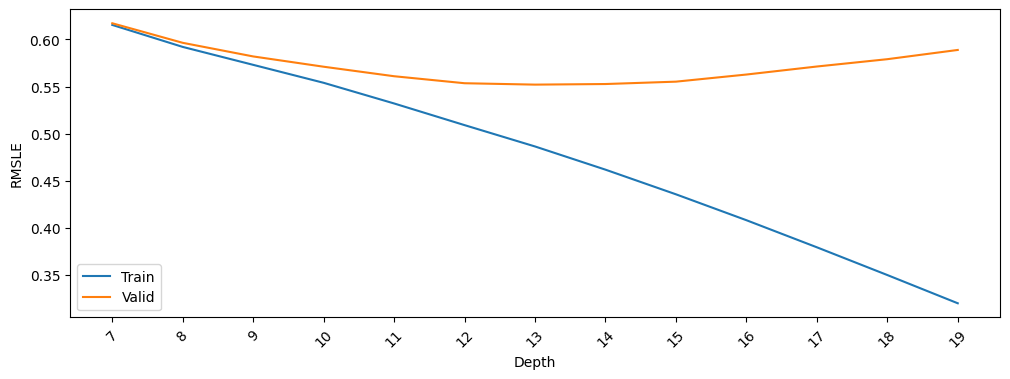

In [34]:
#Визуализируем изменение RMSLE в зависимости от max_depth
fig, ax = plt.subplots(figsize=(12, 4)) #фигура + координатная плоскость
ax.plot(max_depths, train_scores, label='Train') #линейный график для тренировочной выборки
ax.plot(max_depths, test_scores, label='Valid') #линейный график для тестовой выборки
ax.set_xlabel('Depth') #название оси абсцисс
ax.set_ylabel('RMSLE') #название оси ординат
ax.set_xticks(max_depths) #метки по оси абсцисс
ax.xaxis.set_tick_params(rotation=45) #поворот меток на оси абсцисс
ax.legend(); #отображение легенды

**Вывод:**

*График зависимости значение метрики RMSLE на тренировочной и валидационной выборках в зависимости от параметра max_depth показывает, что оптимальное значение max_depth=12. Произведем расчет метрик MAPE и RMSLE с значеним параметра max_depth=12*

In [35]:
#Создаём объект класса DecisionTreeRegressor
dt_regr = tree.DecisionTreeRegressor(max_depth=12, random_state=42)

#Обучаем дерево решений
dt_regr.fit(df_X_train_MinMaxScaler, y_train_log)

# Сделаем предсказание методом predict():
y_predict_train = dt_regr.predict(df_X_train_MinMaxScaler)
y_predict_valid = dt_regr.predict(df_X_valid_MinMaxScaler)

#Рассчитываем метрику MAPE и RMSLE на тренировочной выборке
print('MAPE train score:', round(metrics.mean_absolute_percentage_error(y_train_log, y_predict_train), 4))
print('RMSLE score: {:.3f}'.format((metrics.mean_squared_error(y_train_log, y_predict_train)**0.5)))

#Рассчитываем метрику MAPE и RMSLE на валидационной выборке
print('MAPE valid score:', round(metrics.mean_absolute_percentage_error(y_valid_log, y_predict_valid), 4))
print('RMSLE valid score: {:.3f}'.format((metrics.mean_squared_error(y_valid_log, y_predict_valid)**0.5)))

MAPE train score: 0.029
RMSLE score: 0.509
MAPE valid score: 0.0316
RMSLE valid score: 0.554


**Вывод:**

*Значение метрики MAPE и RMSLE при использовании модели дерева решений с параметром max_depth=11 показали значительно лучше результаты, чем в предыдущих моделях.*

### 5.3. Решение задачи регрессии: Ансамблевые методы

#### 5.3.1 Решение задачи регрессии: Случайный лес (RandomForestRegressor)

Построим модель случайного леса на обучающей выборке. В качестве значений гиперпараметров возьмем параметры по умолчанию

In [27]:
#Создаём объект класса RandomForestRegressor 
rf = ensemble.RandomForestRegressor()
#Обучаем модель
%time rf.fit(df_X_train_MinMaxScaler, y_train_log)
#Делаем предсказание для тренировочной выборки 
y_predict_train_rf = rf.predict(df_X_train_MinMaxScaler)
#Делаем предсказание для валидационной выборки 
y_predict_valid_rf = rf.predict(df_X_valid_MinMaxScaler)

#Рассчитываем метрику MAPE и RMSLE на тренировочной выборке
print('MAPE train score:', round(metrics.mean_absolute_percentage_error(y_train_log, y_predict_train_rf), 4))
print('RMSLE score: {:.3f}'.format((metrics.mean_squared_error(y_train_log, y_predict_train_rf)**0.5)))

#Рассчитываем метрику MAPE и RMSLE на валидационной выборке
print('MAPE valid score:', round(metrics.mean_absolute_percentage_error(y_valid_log, y_predict_valid_rf), 4))
print('RMSLE valid score: {:.3f}'.format((metrics.mean_squared_error(y_valid_log, y_predict_valid_rf)**0.5)))

CPU times: total: 4min 3s
Wall time: 4min 15s
MAPE train score: 0.0094
RMSLE score: 0.182
MAPE valid score: 0.0247
RMSLE valid score: 0.463


**Вывод:**

*Значение метрики MAPE и RMSLE при использовании модели случайный лес с гиперпараметрами по умолчанию показали значительно лучше результаты, чем в предыдущих моделях. Используем метод настройки гиперпараметров RandomizedSearchCV. Т.к настройка с помощью RandomizedSearchCV, требует значительные вычислительные мощъности, то попробуем воспользуемся методом понижения размерности PCA, для ускорения обучения модели и поиска оптимальных гиперпараметров*

#### 5.3.2. Решение задачи регрессии: метод понижения размерности PCA

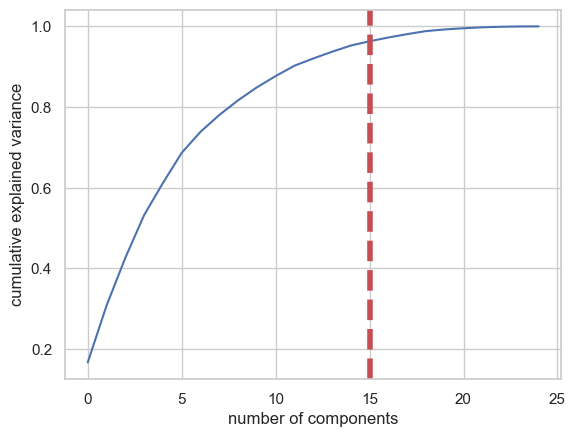

None

,Cumulative Variance Ratio,Explained Variance Ratio
0,0.166560,0.166560
1,0.307375,0.140815
2,0.425918,0.118543
3,0.531882,0.105964
4,0.611387,0.079505
5,0.686236,0.074849
6,0.738420,0.052184
7,0.780140,0.041720
8,0.816572,0.036432
9,0.848666,0.032093


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
pca_test = PCA(n_components=25)
pca_test.fit(df_X_train_MinMaxScaler)
sns.set(style='whitegrid')
plt.plot(np.cumsum(pca_test.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.axvline(linewidth=4, color='r', linestyle = '--', x=15, ymin=0, ymax=1)
display(plt.show())
evr = pca_test.explained_variance_ratio_
cvr = np.cumsum(pca_test.explained_variance_ratio_)
pca_df = pd.DataFrame()
pca_df['Cumulative Variance Ratio'] = cvr
pca_df['Explained Variance Ratio'] = evr
display(pca_df.head(10))

**Вывод:**

*После того, как число используемых компонент превышает 15, рост их количества не очень сильно повышает объяснённую дисперсию. Использование PCA для перехода от 25 переменных к 15 компонентам позволяет объяснить 95% дисперсии данных. Другие 10 компонент объясняют менее 5% дисперсии, а это значит, что от них мы можем отказаться.*

In [38]:
# Снизим количество компонен до 15
pca = PCA(n_components=15)
pca.fit(df_X_train_MinMaxScaler)
X_train_scaled_pca = pca.transform(df_X_train_MinMaxScaler)
X_valid_scaled_pca = pca.transform(df_X_valid_MinMaxScaler)

In [39]:
# Заного посчитаем метрики после понижения размерности объект класса RandomForestRegressor 
rfс = ensemble.RandomForestRegressor()
#Обучаем модель
%time rfс.fit(X_train_scaled_pca, y_train_log)
#Делаем предсказание для тренировочной выборки 
y_predict_train_pca = rfс.predict(X_train_scaled_pca)
#Делаем предсказание для валидационной выборки 
y_predict_valid_pca = rfс.predict(X_valid_scaled_pca)

#Рассчитываем метрику MAPE и RMSLE на тренировочной выборке
print('MAPE train score:', round(metrics.mean_absolute_percentage_error(y_train_log, y_predict_train_pca), 4))
print('RMSLE score: {:.3f}'.format((metrics.mean_squared_error(y_train_log, y_predict_train_pca)**0.5)))

#Рассчитываем метрику MAPE и RMSLE на валидационной выборке
print('MAPE valid score:', round(metrics.mean_absolute_percentage_error(y_valid_log, y_predict_valid_pca), 4))
print('RMSLE valid score: {:.3f}'.format((metrics.mean_squared_error(y_valid_log, y_predict_valid_pca)**0.5)))

CPU times: total: 9min 37s
Wall time: 9min 39s
MAPE train score: 0.011
RMSLE score: 0.202
MAPE valid score: 0.029
RMSLE valid score: 0.519


**Вывод:**

*Уменьшение кол-ва компонент методом PCA привело к существенному снижению качества модели на валидационной выборке без уменьшения времени обучения модели. Поэтому в дальнейшем, будем использовать данные без применения метода PCA* 

#### 5.3.3. Решение задачи регрессии: подбор оптимальных гиперпараметров

Для подбора гиперпараметров модели случайный лес будем использовать RandomizedSearchCV

In [78]:
# Подберем оптимальниые гиперпараметры с помощью RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {'n_estimators': list(range(100, 500, 5)),
              'min_samples_split': list(np.linspace(2, 50, 5, dtype=int)),
              'min_samples_leaf': list(np.linspace(1, 5, 5, dtype=int)),
              'max_depth': list(np.linspace(1, 15, 10, dtype=int))
              }
            
random_search_forest = RandomizedSearchCV(
    estimator=ensemble.RandomForestRegressor(random_state=42), 
    param_distributions=param_distributions, 
    cv=3,
    n_iter = 10, 
    n_jobs = -1,
    random_state=42
)  
%time random_search_forest.fit(df_X_train_MinMaxScaler, y_train_log) 
random_search_forest.best_params_

CPU times: total: 7min 51s
Wall time: 42min 26s


{'n_estimators': 350,
 'min_samples_split': np.int64(2),
 'min_samples_leaf': np.int64(3),
 'max_depth': np.int64(13)}

In [84]:
#Делаем предсказание для тренировочной выборки для оптимальных гиперпараметров подобранных с помощью RandomizedSearchCV
y_predict_train = random_search_forest.predict(df_X_train_MinMaxScaler)
#Делаем предсказание для валидационной выборки для оптимальных гиперпараметров подобранных с помощью RandomizedSearchCV
y_predict_valid = random_search_forest.predict(df_X_valid_MinMaxScaler)

#Рассчитываем метрику MAPE и RMSLE на тренировочной выборке
print('MAPE train score:', round(metrics.mean_absolute_percentage_error(y_train_log, y_predict_train), 4))
print('RMSLE score: {:.3f}'.format((metrics.mean_squared_error(y_train_log, y_predict_train)**0.5)))

#Рассчитываем метрику MAPE и RMSLE на валидационной выборке
print('MAPE valid score:', round(metrics.mean_absolute_percentage_error(y_valid_log, y_predict_valid), 4))
print('RMSLE valid score: {:.3f}'.format((metrics.mean_squared_error(y_valid_log, y_predict_valid)**0.5)))

MAPE train score: 0.0261
RMSLE score: 0.461
MAPE valid score: 0.0286
RMSLE valid score: 0.505


**Вывод:**

*Значение метрики MAPE и RMSLE при использовании модели случайный лес с гиперпараметрами подобранными с помощью RandomizedSearchCV показали значения хуже, чем при использовании параметров по умолчанию. Оставляем модель RandomForestRegressor с параметрами по умолчанию, т.к. данная комбинация показала наилучшее качество из всех использованных моделей. Произведем исследование о важности признаков для модели случайный лес (RandomForestRegressor), используя коэффициенты значимости каждого из факторов*

#### 5.3.4. Решение задачи регрессии: определение коэффициентов значимости каждого из факторов для модели случайный лес

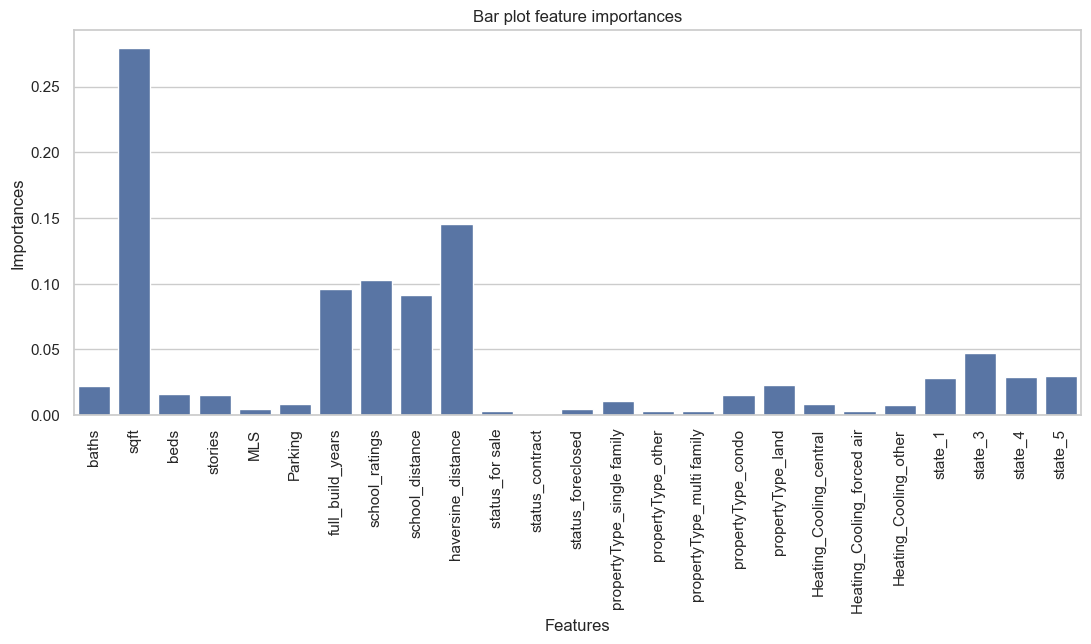

In [50]:
#Построим столбчатую диаграмму коэффициентов значимости каждого из факторов для модели случайный лес, показавшей наилучшее качество

fig, ax = plt.subplots(figsize=(13, 5)) #фигура + координатная плоскость
feature = df_X_train_MinMaxScaler.columns #признаки
feature_importances = rf.feature_importances_ #важность признаков
#Строим столбчатую диаграмму
sns.barplot(x=feature, y=feature_importances, ax=ax);
#Добавляем подпись графику, осям абцисс и ординат
ax.set_title('Bar plot feature importances')
ax.set_xlabel('Features')
ax.set_ylabel('Importances');
ax.xaxis.set_tick_params(rotation=90) #поворот меток на оси абсцисс

**Вывод:**

*Столбчатая диаграмма коэффициентов значимости каждого из факторов показывает, что наиболее важные признаки для определения целевого признака с помощью наилучшей модели случайного леса:*
- *sqft*
- *haversine_distance*
- *school_rating*
- *school_distance*

#### 5.4.1. Решение задачи регрессии:  Градиентный бустинг над деревьями решений (GradientBoostingRegressor)

Попробуем еще одну модель Градиентный бустинг над деревьями решений (GradientBoostingRegressor). В качестве значений гиперпараметров возьмем параметры по умолчанию

In [49]:
#Создаём объект класса GradientBoostingRegressor
gbr = ensemble.GradientBoostingRegressor()
#Обучаем модель
gbr.fit(df_X_train_MinMaxScaler, y_train_log)
#Делаем предсказание для тренировочной выборки 
y_predict_train = gbr.predict(df_X_train_MinMaxScaler)
#Делаем предсказание для валидационной выборки 
y_predict_valid = gbr.predict(df_X_valid_MinMaxScaler)

#Рассчитываем метрику MAPE и RMSLE на тренировочной выборке
print('MAPE train score:', round(metrics.mean_absolute_percentage_error(y_train_log, y_predict_train), 4))
print('RMSLE score: {:.3f}'.format((metrics.mean_squared_error(y_train_log, y_predict_train)**0.5)))

#Рассчитываем метрику MAPE и RMSLE на валидационной выборке
print('MAPE valid score:', round(metrics.mean_absolute_percentage_error(y_valid_log, y_predict_valid), 4))
print('RMSLE valid score: {:.3f}'.format((metrics.mean_squared_error(y_valid_log, y_predict_valid)**0.5)))

MAPE train score: 0.0331
RMSLE score: 0.563
MAPE valid score: 0.0332
RMSLE valid score: 0.563


**Вывод:**

*Значение метрики MAPE и RMSLE при использовании модели градиентный бустинг над деревьями решений с параметрами по умолчанию показали значения хуже, чем при использовании модели случайный лес (RandomForestRegressor). Оставляем модель RandomForestRegressor с параметрами по умолчанию, т.к. данная комбинация показала наилучшее качество из всех использованных моделей. Для модели случайный лес произведем обучение с использованием крос-валидации на 5ти фолдах с расчетом метрики RMSLE.*

#### 5.5.1. Решение задачи регрессии:  Экстремальный градиентный бустинг (Xgboost)

Перед обучением модели переведем наборы данных в тип данных xgboost.DMatrix:

In [83]:
import xgboost as xgb

df_X_train_MinMaxScaler = df_X_train_MinMaxScaler.rename(columns={'state_1': 'state_1.0',
                                                                  'state_3': 'state_3.0',
                                                                  'state_4': 'state_4.0',
                                                                  'state_5': 'state_5.0',
                                                                 })
df_X_valid_MinMaxScaler = df_X_valid_MinMaxScaler.rename(columns={'state_1': 'state_1.0',
                                                                  'state_3': 'state_3.0',
                                                                  'state_4': 'state_4.0',
                                                                  'state_5': 'state_5.0',
                                                                 })


In [99]:
#разбиваем валидационную выборку на валидационную и тестовую в соотношении 50/50
X_valid, X_test, y_valid_log, y_test_log = model_selection.train_test_split(df_X_valid_MinMaxScaler, y_valid_log, test_size=0.5, random_state=42)

# Создание матриц наблюдений в формате DMatrix
dtrain = xgb.DMatrix(df_X_train_MinMaxScaler, label=y_train_log, enable_categorical=True)
dvalid = xgb.DMatrix(X_valid, label=y_valid_log, enable_categorical=True)
dtest = xgb.DMatrix(X_test,  enable_categorical=True)

In [71]:
# Гиперпараметры модели
xgb_pars = {'min_child_weight': 20, 'eta': 0.1, 'colsample_bytree': 0.9, 
            'max_depth': 6, 'subsample': 0.9, 'lambda': 1, 'nthread': -1, 
            'booster' : 'gbtree', 'eval_metric': 'rmse', 'objective': 'reg:squarederror'
           }
# Тренировочная и валидационная выборка
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]
# Обучаем модель XGBoost
model = xgb.train(
    params=xgb_pars, #гиперпараметры модели
    dtrain=dtrain, #обучающая выборка
    num_boost_round=500, #количество моделей в ансамбле
    evals=watchlist, #выборки, на которых считается матрица
    early_stopping_rounds=20, #раняя остановка
    maximize=False, #смена поиска максимума на минимум
    verbose_eval=10 #шаг, через который происходит отображение метрик
)

[0]	train-rmse:0.77388	valid-rmse:0.77178
[10]	train-rmse:0.62819	valid-rmse:0.62840
[20]	train-rmse:0.57906	valid-rmse:0.58061
[30]	train-rmse:0.55460	valid-rmse:0.55677
[40]	train-rmse:0.53756	valid-rmse:0.54008
[50]	train-rmse:0.52905	valid-rmse:0.53207
[60]	train-rmse:0.52123	valid-rmse:0.52454
[70]	train-rmse:0.51726	valid-rmse:0.52091
[80]	train-rmse:0.51330	valid-rmse:0.51752
[90]	train-rmse:0.51024	valid-rmse:0.51501
[100]	train-rmse:0.50747	valid-rmse:0.51276
[110]	train-rmse:0.50534	valid-rmse:0.51120
[120]	train-rmse:0.50275	valid-rmse:0.50905
[130]	train-rmse:0.50031	valid-rmse:0.50706
[140]	train-rmse:0.49771	valid-rmse:0.50491
[150]	train-rmse:0.49561	valid-rmse:0.50316
[160]	train-rmse:0.49333	valid-rmse:0.50140
[170]	train-rmse:0.49102	valid-rmse:0.49970
[180]	train-rmse:0.48910	valid-rmse:0.49834
[190]	train-rmse:0.48681	valid-rmse:0.49659
[200]	train-rmse:0.48520	valid-rmse:0.49558
[210]	train-rmse:0.48320	valid-rmse:0.49412
[220]	train-rmse:0.48147	valid-rmse:0.49286

In [96]:
#Делаем предсказание на тестовом наборе данных
y_test_predict = np.exp(model.predict(dtest)) - 1
print('Modeling RMSLE %.5f' % model.best_score)

Modeling RMSLE 0.47876


#### 5.5.2. Решение задачи регрессии: определение коэффициентов значимости каждого из факторов для модели Экстремальный градиентный бустинг (Xgboost)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

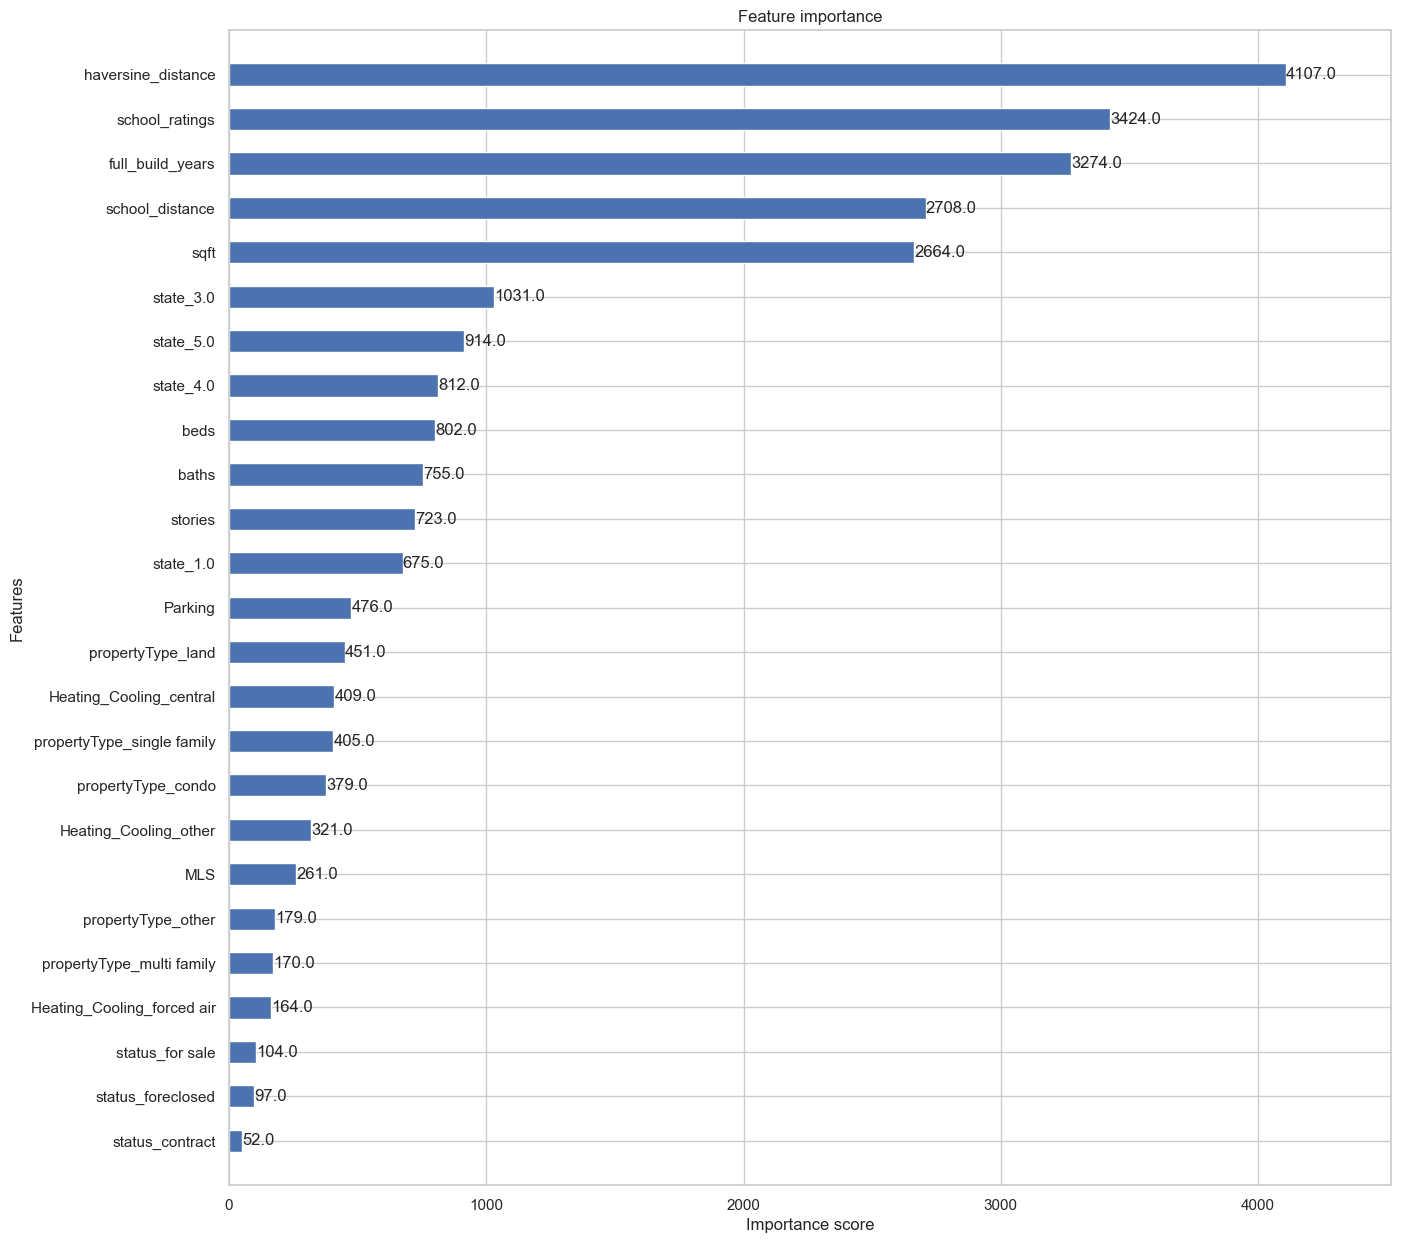

In [66]:
#Определим коэффициенты важности факторов
fig, ax = plt.subplots(figsize = (15,15))
xgb.plot_importance(model, ax = ax, height=0.5)

**Вывод:**

*Столбчатая диаграмма коэффициентов значимости каждого из факторов показывает, что наиболее важные признаки для определения целевого признака с помощью наилучшей модели случайного леса:*
- *haversine_distance*
- *school_rating*
- *full_build_years*

## 6. Вывод

Для лучшей из построенных моделей **случайный лес** с параметрами по умолчанию рассчитаем медианную абсолютную ошибку (MeAE - median_absolute_error) предсказания стоимости объекта недвижимости на валидационной выборке:
$$ MeAE = median(|y_i-\hat{y_i}|)$$

In [43]:
print('Методом SelectKBest было отобрано 25 признаков, наилучшим образом подходящих для предсказания целевой переменной. Это позволило улучшить качество и скорость обучения модели. Наилучшее качество предсказания стоимости недвижимости получилось у модели случайный лес RandomForestRegressor с параметрами по умолчанию. Наилучшее значение метрики для данной модели - медианная абсолютная ошибка MeAE score: {:.1f} $'.format(metrics.median_absolute_error(np.exp(y_train_log)-1, np.exp(y_predict_train_rf)-1)), 'с учетом, что средняя медианная стоимость всех объектов недвижимости составляет:{:.1f} $'.format(np.exp(df_temp_filtered.target.median())-1), 'При этом ошибка предсказания на валидационной выборке по метрике MAPE составила {:.1f} %:'.format(metrics.mean_absolute_percentage_error(y_valid_log, y_predict_valid_rf)*100), 'Методы понижения размерности PCA и подбора оптимальных гиперпараметров RandomizedSearchCV не показали улучение качества модели.')

Методом SelectKBest было отобрано 25 признаков, наилучшим образом подходящих для предсказания целевой переменной. Это позволило улучшить качество и скорость обучения модели. Наилучшее качество предсказания стоимости недвижимости получилось у модели случайный лес RandomForestRegressor с параметрами по умолчанию. Наилучшее значение метрики для данной модели - медианная абсолютная ошибка MeAE score: 20972.4 $ с учетом, что средняя медианная стоимость всех объектов недвижимости составляет:314990.0 $ При этом ошибка предсказания на валидационной выборке по метрике MAPE составила 2.5 %: Методы понижения размерности PCA и подбора оптимальных гиперпараметров RandomizedSearchCV не показали улучение качества модели.


Модели случайный лес RandomForestRegressor и Экстремальный градиентный бустинг определили, что наибольшие коэффициенты значимости получились для признаков:*
- *sqft*
- *haversine_distance*
- *school_rating*
- *full_build_years*
- *school_distance*

## 7. Вывод модели в продакшен

В папке Diploma_project/web разработан небольшой веб-сервис состоящий из файлов server.py и client.py, на вход которому поступают данные о некоторой выставленной на продажу недвижимости, а сервис прогнозирует его стоимость. Необходимо сначало сохранить модель в папку web/models, через pickle(код сохранения указан ниже).

In [59]:
# Производим сериализацию и записываем результат в файл формата pkl
with open('web/models/model.pkl', 'wb') as output:
    pickle.dump(rf, output)

Далее необходимо поочереди отдельно в каждом терминале запустить в начале файл server.py, затем client.py
Модель произведет предсказания по значениям указаным в файле client.py